In [ ]:
# ============================================================
# IMPORTING ALL LIBRARIES
# ============================================================

# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Train-Test Split
from sklearn.model_selection import train_test_split

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Logistic Regression
from sklearn.linear_model import LogisticRegression

# Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

In [2]:
# ============================================================
#LOAD THE TRAINING AND TEST DATA
# ============================================================

# Read the training CSV file.
# The training data contains both the input features and
# the target variable "Revenue".
original_df = pd.read_csv("train.csv")

# Read the test CSV file.
# The test data contains the input features but does NOT
# contain the hidden target "Revenue".
test_df = pd.read_csv("test.csv")

# Display the first five rows of the training dataset.
original_df.head()

,Session_ID,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,112163,0,0.00,0,0.0,3,44.500000,0.066667,0.133333,0.000000,0.0,Dec,2,2,9.0,3.0,Returning_Visitor,False,False
1,107490,0,0.00,0,0.0,12,460.200000,0.061111,0.111111,0.000000,0.0,Jul,2,2,6.0,4.0,Returning_Visitor,False,False
2,106273,4,48.80,0,0.0,11,344.800000,0.015385,0.054396,0.000000,0.0,Oct,3,2,1.0,4.0,Returning_Visitor,True,False
3,110651,0,0.00,0,0.0,23,517.035714,0.000000,0.009524,23.300007,0.0,Dec,4,2,8.0,2.0,New_Visitor,False,True
4,101259,7,110.25,0,0.0,20,266.583333,0.011111,0.039753,0.000000,0.0,Mar,2,2,1.0,2.0,Returning_Visitor,False,False


In [3]:
# ============================================================
# BASIC DATASET INSPECTION
# ============================================================

# Display the number of rows and columns in the training data.
print("Training data shape:", original_df.shape)

# Display the number of rows and columns in the test data.
print("Test data shape:", test_df.shape)

# Display the names of all columns in the training dataset.
print("\nTraining columns:")
print(original_df.columns.tolist())

# Display the data type of every column.
# This helps us identify numerical, categorical and boolean variables.
print("\nColumn data types:")
print(original_df.dtypes)

# Display the first five rows so that we can visually
# understand what the dataset looks like.
print("\nFirst five rows:")
display(original_df.head())

Training data shape: (9864, 19)
Test data shape: (2466, 18)

Training columns:
['Session_ID', 'Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend', 'Revenue']

Column data types:
Session_ID                   int64
Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                       object
OperatingSystems             int64
Browser                      int64
Region                     float64
TrafficType                float64
VisitorType                 object


,Session_ID,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,112163,0,0.00,0,0.0,3,44.500000,0.066667,0.133333,0.000000,0.0,Dec,2,2,9.0,3.0,Returning_Visitor,False,False
1,107490,0,0.00,0,0.0,12,460.200000,0.061111,0.111111,0.000000,0.0,Jul,2,2,6.0,4.0,Returning_Visitor,False,False
2,106273,4,48.80,0,0.0,11,344.800000,0.015385,0.054396,0.000000,0.0,Oct,3,2,1.0,4.0,Returning_Visitor,True,False
3,110651,0,0.00,0,0.0,23,517.035714,0.000000,0.009524,23.300007,0.0,Dec,4,2,8.0,2.0,New_Visitor,False,True
4,101259,7,110.25,0,0.0,20,266.583333,0.011111,0.039753,0.000000,0.0,Mar,2,2,1.0,2.0,Returning_Visitor,False,False


In [4]:
# ============================================================
# CHECK MISSING VALUES
# ============================================================

# Count the number of missing values in every column.
# isnull() returns True wherever a value is missing.
# sum() then counts those True values column-wise.
missing_values = original_df.isnull().sum()

# Create a small table containing:
# 1. Column name
# 2. Number of missing values
# 3. Percentage of values that are missing
missing_summary = pd.DataFrame({
    "missing_count": missing_values,
    "missing_percentage": (missing_values / len(original_df)) * 100
})

# Sort the result so that columns with the largest number
# of missing values appear at the top.
missing_summary = missing_summary.sort_values(
    by="missing_count",
    ascending=False
)

# Display the missing-value summary.
display(missing_summary)

# Calculate the TOTAL number of missing values in the
# complete original training dataset.
total_missing = original_df.isnull().sum().sum()

print("\nTotal missing values in original training data:", total_missing)

,missing_count,missing_percentage
TrafficType,789,7.998783
ExitRates,691,7.005272
Region,591,5.991484
Administrative_Duration,492,4.987835
VisitorType,394,3.994323
Session_ID,0,0.000000
Month,0,0.000000
Weekend,0,0.000000
Browser,0,0.000000
OperatingSystems,0,0.000000



Total missing values in original training data: 2957


Number of completely duplicated rows: 0
Number of duplicated Session_ID values: 0

Revenue class counts:
Revenue
False    8211
True     1653
Name: count, dtype: int64

Revenue class percentages:
Revenue
False    83.242092
True     16.757908
Name: proportion, dtype: float64


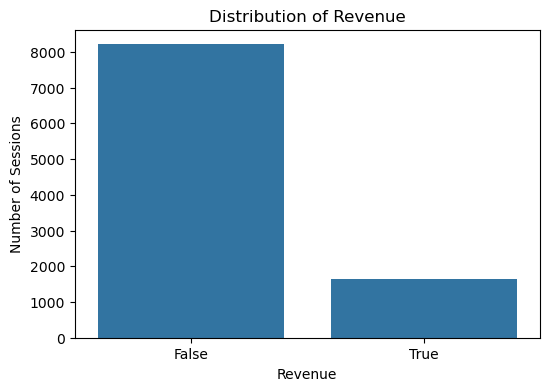

In [5]:
# ============================================================
# CHECK DUPLICATES AND TARGET DISTRIBUTION
# ============================================================

# Count completely duplicated rows in the original training data.
duplicate_rows = original_df.duplicated().sum()

print("Number of completely duplicated rows:", duplicate_rows)

# Check whether Session_ID is duplicated.
# Session_ID should identify individual sessions, so duplicate
# IDs are worth investigating before modelling.
duplicate_session_ids = original_df["Session_ID"].duplicated().sum()

print("Number of duplicated Session_ID values:", duplicate_session_ids)

# ------------------------------------------------------------
# TARGET VARIABLE
# ------------------------------------------------------------

# Count how many observations belong to each Revenue class.
revenue_counts = original_df["Revenue"].value_counts()

print("\nRevenue class counts:")
print(revenue_counts)

# Convert the counts into percentages.
revenue_percentage = original_df["Revenue"].value_counts(normalize=True) * 100

print("\nRevenue class percentages:")
print(revenue_percentage)

# Plot the target distribution.
plt.figure(figsize=(6, 4))

sns.countplot(
    data=original_df,
    x="Revenue"
)

plt.title("Distribution of Revenue")
plt.xlabel("Revenue")
plt.ylabel("Number of Sessions")

plt.show()

In [6]:
# ============================================================
#  SEPARATE FEATURES (X) AND TARGET (y)
# ============================================================

# X contains the input variables that the Logistic Regression
# model will use to make predictions.
#
# We remove Revenue because Revenue is the answer we are
# trying to predict, not an input feature.
X = original_df.drop(columns=["Revenue"])

# y contains only the target variable.
# This is what the Logistic Regression model will learn to predict.
y = original_df["Revenue"]

# Display the shapes so we can verify the separation.
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

# Display the first few rows of the input features.
print("\nInput features:")
display(X.head())

# Display the first few target values.
print("\nTarget values:")
display(y.head())

Shape of X: (9864, 18)
Shape of y: (9864,)

Input features:


,Session_ID,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend
0,112163,0,0.00,0,0.0,3,44.500000,0.066667,0.133333,0.000000,0.0,Dec,2,2,9.0,3.0,Returning_Visitor,False
1,107490,0,0.00,0,0.0,12,460.200000,0.061111,0.111111,0.000000,0.0,Jul,2,2,6.0,4.0,Returning_Visitor,False
2,106273,4,48.80,0,0.0,11,344.800000,0.015385,0.054396,0.000000,0.0,Oct,3,2,1.0,4.0,Returning_Visitor,True
3,110651,0,0.00,0,0.0,23,517.035714,0.000000,0.009524,23.300007,0.0,Dec,4,2,8.0,2.0,New_Visitor,False
4,101259,7,110.25,0,0.0,20,266.583333,0.011111,0.039753,0.000000,0.0,Mar,2,2,1.0,2.0,Returning_Visitor,False



Target values:


0    False
1    False
2    False
3     True
4    False
Name: Revenue, dtype: bool

In [7]:
# ============================================================
#  IDENTIFY NUMERICAL AND CATEGORICAL FEATURES
# ============================================================

# We do not want Session_ID to be used as a model feature.
# It is only an identifier used later to match predictions
# with the correct test sessions.
#
# Therefore, remove Session_ID from X before identifying
# the columns that will actually go into the model.
X_model = X.drop(columns=["Session_ID"])

# Select all numerical columns.
# These are columns containing numbers such as:
# page counts, durations, rates, values, etc.
numerical_cols = X_model.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

# Select all categorical/object columns.
# These contain values such as month names or visitor types.
categorical_cols = X_model.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

# Display both groups.
print("Numerical columns:")
print(numerical_cols)

print("\nCategorical columns:")
print(categorical_cols)

print("\nNumber of numerical columns:", len(numerical_cols))
print("Number of categorical columns:", len(categorical_cols))

Numerical columns:
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'OperatingSystems', 'Browser', 'Region', 'TrafficType']

Categorical columns:
['Month', 'VisitorType', 'Weekend']

Number of numerical columns: 14
Number of categorical columns: 3


In [8]:
# ============================================================
#  INSPECT CATEGORICAL VARIABLES
# ============================================================

# Loop through every categorical column.
# For each column, display its unique values.
for column in categorical_cols:

    print("\n" + "=" * 60)
    print("Column:", column)

    # unique() shows the different values present in the column.
    print("Unique values:")
    print(X_model[column].unique())

    # nunique() tells us how many different categories exist.
    print("Number of unique values:", X_model[column].nunique())


Column: Month
Unique values:
['Dec' 'Jul' 'Oct' 'Mar' 'Nov' 'Aug' 'May' 'June' 'Feb' 'Sep']
Number of unique values: 10

Column: VisitorType
Unique values:
['Returning_Visitor' 'New_Visitor' nan 'Other']
Number of unique values: 3

Column: Weekend
Unique values:
[False  True]
Number of unique values: 2


In [9]:
# ============================================================
#  INSPECT NUMERICAL FEATURES
# ============================================================

# describe() gives us statistical information about
# the numerical columns.
#
# count  -> number of non-missing observations
# mean   -> average
# std    -> standard deviation
# min    -> minimum
# 25%    -> first quartile
# 50%    -> median
# 75%    -> third quartile
# max    -> maximum
#
# This helps us understand the scale and distribution
# of the numerical variables before scaling them.
numerical_summary = X_model[numerical_cols].describe().T

display(numerical_summary)

,count,mean,std,min,25%,50%,75%,max
Administrative,9864.0,2.316910,3.346879,0.0,0.000000,1.000000,4.000000,27.000000
Administrative_Duration,9372.0,81.611336,181.566335,0.0,0.000000,7.000000,93.500000,3398.750000
Informational,9864.0,0.500000,1.268721,0.0,0.000000,0.000000,0.000000,24.000000
Informational_Duration,9864.0,33.925878,138.415311,0.0,0.000000,0.000000,0.000000,2549.375000
ProductRelated,9864.0,31.693025,44.596694,0.0,7.000000,18.000000,38.000000,705.000000
ProductRelated_Duration,9864.0,1190.378574,1943.270384,0.0,183.000000,593.725990,1449.152083,63973.522230
BounceRates,9864.0,0.022155,0.048262,0.0,0.000000,0.003080,0.016866,0.200000
ExitRates,9173.0,0.044035,0.049444,0.0,0.014286,0.025556,0.050000,0.200000
PageValues,9864.0,5.911717,18.785453,0.0,0.000000,0.000000,0.000000,361.763742
SpecialDay,9864.0,0.061354,0.199011,0.0,0.000000,0.000000,0.000000,1.000000


In [10]:
# ============================================================
#  CONVERT THE TARGET VARIABLE TO 0 AND 1
# ============================================================

# Revenue is our target variable.
#
# At the moment, its values are:
#
# False -> no purchase
# True  -> purchase
#
# Logistic Regression works with numerical target values,
# so we convert:
#
# False -> 0
# True  -> 1

y = original_df["Revenue"].astype(int)

# Check the result.
print("Unique values after conversion:")
print(y.unique())

# Check how many observations belong to each class.
print("\nTarget class counts:")
print(y.value_counts())

# Check the class percentages.
print("\nTarget class percentages:")
print(y.value_counts(normalize=True) * 100)

Unique values after conversion:
[0 1]

Target class counts:
Revenue
0    8211
1    1653
Name: count, dtype: int64

Target class percentages:
Revenue
0    83.242092
1    16.757908
Name: proportion, dtype: float64


In [11]:
# ============================================================
# VERIFY ORIGINAL DATA AND TARGET
# ============================================================

# Check the original Revenue column.
print("Revenue values in original_df:")
print(original_df["Revenue"].unique())

# Check the converted target used for modelling.
print("\nRevenue values in y:")
print(y.unique())

# Confirm that X and y have the same number of observations.
print("\nNumber of rows in X:", len(X))
print("Number of rows in y:", len(y))

# Confirm that there are no missing target values.
print("\nMissing values in target:", y.isnull().sum())

Revenue values in original_df:
[False  True]

Revenue values in y:
[0 1]

Number of rows in X: 9864
Number of rows in y: 9864

Missing values in target: 0


In [12]:
# ============================================================
#  TRAIN / VALIDATION SPLIT
# ============================================================

# X contains the input features from train.csv.
# y contains the Revenue target (0 = no purchase, 1 = purchase).
#
# We are splitting ONLY the training dataset here.
# test_df is NOT involved in this split because its Revenue
# values are hidden.

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,          # Keep 20% of the training data for validation
    random_state=42,        # Makes the split reproducible
    stratify=y              # Keeps the True/False class proportion similar
)

# Display the resulting sizes.
print("Original training data:", X.shape)

print("\nTraining portion:", X_train.shape)
print("Validation portion:", X_val.shape)

print("\nTraining target:", y_train.shape)
print("Validation target:", y_val.shape)

# Check the Revenue distribution in both portions.
print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nValidation target distribution:")
print(y_val.value_counts(normalize=True))

Original training data: (9864, 18)

Training portion: (7891, 18)
Validation portion: (1973, 18)

Training target: (7891,)
Validation target: (1973,)

Training target distribution:
Revenue
0    0.832467
1    0.167533
Name: proportion, dtype: float64

Validation target distribution:
Revenue
0    0.832235
1    0.167765
Name: proportion, dtype: float64


In [13]:
# ============================================================
#  CREATE THE PREPROCESSING PIPELINE
# ============================================================

from sklearn.impute import SimpleImputer

# ------------------------------------------------------------
# NUMERICAL PREPROCESSING
# ------------------------------------------------------------

# Numerical columns may contain missing values.
#
# We use the median to fill missing numerical values.
#
# Why median?
# The median is less affected by extreme values than the mean.
# This is useful because some session-related numerical
# variables can have unusual/extreme values.
#
# After filling missing values, StandardScaler standardizes
# the numerical features.
numerical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)


# ------------------------------------------------------------
# CATEGORICAL PREPROCESSING
# ------------------------------------------------------------

# Categorical columns can also contain missing values.
#
# We replace missing categorical values with the most frequent
# category found in the training data.
#
# Then OneHotEncoder converts categories into numerical columns
# that Logistic Regression can use.
categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)


# ------------------------------------------------------------
# COMBINE BOTH PREPROCESSING METHODS
# ------------------------------------------------------------

# ColumnTransformer allows us to apply the numerical pipeline
# to numerical columns and the categorical pipeline to
# categorical columns.
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_transformer,
            numerical_cols
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_cols
        )
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [14]:
# ============================================================
#  CREATE LOGISTIC REGRESSION PIPELINE
# ============================================================

# Create the complete machine-learning pipeline.
#
# First:
#     preprocessor
#
# will clean, encode and scale the input data.
#
# Then:
#     LogisticRegression
#
# will receive the processed numerical features and learn
# how they are related to Revenue.
model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                random_state=42
            )
        )
    ]
)

print("Logistic Regression pipeline created successfully.")
print(model)

Logistic Regression pipeline created successfully.
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Administrative',
                                                   'Administrative_Duration',
                                                   'Informational',
                                                   'Informational_Duration',
                                                   'ProductRelated',
                                                   'ProductRelated_Duration',
                                                   'BounceRates', 'Ex

In [15]:
# ============================================================
#  TRAIN THE LOGISTIC REGRESSION MODEL
# ============================================================

# The pipeline contains two stages:
#
# 1. preprocessor
#    - fills missing numerical values
#    - scales numerical features
#    - fills missing categorical values
#    - one-hot encodes categorical features
#
# 2. classifier
#    - Logistic Regression
#
# When we call fit(), the preprocessing is learned ONLY from
# X_train. This is important because X_val must remain unseen
# while the model is being trained.
#
# y_train contains:
#     0 = Revenue is False (no purchase)
#     1 = Revenue is True  (purchase)

model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [16]:
# ============================================================
#  PREDICT ON THE VALIDATION DATA
# ============================================================

# Use the trained pipeline to make predictions for the
# validation dataset.
#
# The validation data goes through the SAME preprocessing
# learned from X_train.
#
# We do NOT call fit() here.
# We only call predict().
y_val_pred = model.predict(X_val)

# Logistic Regression can also provide the probability
# of belonging to each class.
#
# [:, 1] selects the probability of class 1,
# which represents Revenue = True.
y_val_probability = model.predict_proba(X_val)[:, 1]

# Display a few actual and predicted values side by side.
validation_results = pd.DataFrame({
    "Actual_Revenue": y_val.values,
    "Predicted_Revenue": y_val_pred,
    "Purchase_Probability": y_val_probability
})

display(validation_results.head(10))

,Actual_Revenue,Predicted_Revenue,Purchase_Probability
0,0,0,0.179018
1,0,0,0.259842
2,0,0,0.112877
3,0,0,0.155649
4,1,0,0.377997
5,0,0,0.082862
6,0,0,0.106512
7,0,0,0.062096
8,0,0,0.126993
9,1,0,0.499757


In [17]:
# ============================================================
# EVALUATE LOGISTIC REGRESSION
# ============================================================

# Calculate the percentage of validation observations
# that were classified correctly.
accuracy = accuracy_score(y_val, y_val_pred)

# Precision tells us, among the sessions predicted as
# purchases, how many actually resulted in a purchase.
precision = precision_score(y_val, y_val_pred, zero_division=0)

# Recall tells us, among the sessions that actually resulted
# in purchases, how many our model successfully detected.
recall = recall_score(y_val, y_val_pred, zero_division=0)

# F1-score provides a balance between precision and recall.
f1 = f1_score(y_val, y_val_pred, zero_division=0)

# ROC-AUC evaluates the ranking quality of the predicted
# probabilities rather than only the final 0/1 predictions.
roc_auc = roc_auc_score(y_val, y_val_probability)

print("Validation Results")
print("=" * 40)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_val,
    y_val_pred,
    target_names=["No Purchase", "Purchase"],
    zero_division=0
))

Validation Results
Accuracy : 0.8672
Precision: 0.7674
Recall   : 0.2991
F1 Score : 0.4304
ROC-AUC  : 0.8586

Classification Report:
              precision    recall  f1-score   support

 No Purchase       0.87      0.98      0.92      1642
    Purchase       0.77      0.30      0.43       331

    accuracy                           0.87      1973
   macro avg       0.82      0.64      0.68      1973
weighted avg       0.86      0.87      0.84      1973



Confusion Matrix:
[[1612   30]
 [ 232   99]]


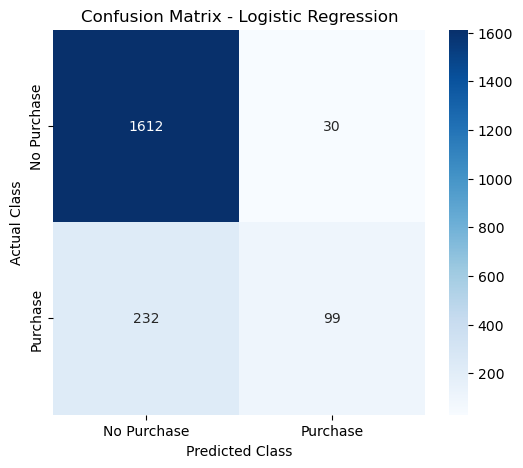

In [18]:
# ============================================================
# CONFUSION MATRIX
# ============================================================

# A confusion matrix shows how the model classified the
# validation observations compared with their actual values.
#
# The arrangement is:
#
#                    PREDICTED
#                  0          1
#
# ACTUAL  0       TN         FP
#         1       FN         TP
#
# TN = True Negative
#     Actual = No Purchase
#     Predicted = No Purchase
#
# FP = False Positive
#     Actual = No Purchase
#     Predicted = Purchase
#
# FN = False Negative
#     Actual = Purchase
#     Predicted = No Purchase
#
# TP = True Positive
#     Actual = Purchase
#     Predicted = Purchase

cm = confusion_matrix(y_val, y_val_pred)

print("Confusion Matrix:")
print(cm)


# Create a visual representation of the confusion matrix.
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Purchase", "Purchase"],
    yticklabels=["No Purchase", "Purchase"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()

In [19]:
# ============================================================
#  TEST DIFFERENT LOGISTIC REGRESSION PARAMETERS
# ============================================================

from sklearn.model_selection import GridSearchCV

# ------------------------------------------------------------
# CREATE A PARAMETER GRID
# ------------------------------------------------------------

# C controls the strength of regularization.
#
# Smaller C:
#     stronger regularization
#
# Larger C:
#     weaker regularization
#
# We test several values instead of assuming that the default
# value is automatically the best one.
#
# class_weight=None:
#     Treat both classes using their normal frequencies.
#
# class_weight="balanced":
#     Give more importance to the minority class.
#
# We are testing both because the dataset has considerably
# more "No Purchase" observations than "Purchase" observations.
parameter_grid = {
    "classifier__C": [0.01, 0.1, 1, 10, 100],
    "classifier__class_weight": [None, "balanced"]
}


# ------------------------------------------------------------
# GRID SEARCH
# ------------------------------------------------------------

# GridSearchCV trains several versions of our Logistic
# Regression pipeline and compares their performance.
#
# scoring="accuracy" is used because accuracy is the official
# competition evaluation metric.
#
# cv=5 means that the training portion is internally divided
# into 5 folds so that the parameter comparison is more
# reliable than relying on only one random split.
#
# n_jobs=-1 allows sklearn to use available CPU cores.
grid_search = GridSearchCV(
    estimator=model,
    param_grid=parameter_grid,
    scoring="accuracy",
    cv=5,
    n_jobs=-1
)


# IMPORTANT:
# Grid search is performed ONLY on X_train and y_train.
#
# X_val remains untouched and will be used later to judge
# whether the selected configuration actually generalizes.
grid_search.fit(X_train, y_train)


# ------------------------------------------------------------
# DISPLAY BEST RESULT
# ------------------------------------------------------------

print("Best parameters:")
print(grid_search.best_params_)

print("\nBest cross-validation accuracy:")
print(grid_search.best_score_)

Best parameters:
{'classifier__C': 1, 'classifier__class_weight': None}

Best cross-validation accuracy:
0.8647839875552945


In [20]:
# ============================================================
# EVALUATE THE TUNED MODEL
# ============================================================

# grid_search.best_estimator_ contains the complete pipeline
# with the best Logistic Regression parameters found during
# cross-validation.
#
# It includes:
#     - missing-value handling
#     - scaling
#     - categorical encoding
#     - Logistic Regression
best_model = grid_search.best_estimator_


# Make predictions on the validation data.
#
# Notice that we are using X_val here, which was NOT used
# during the GridSearchCV fitting process.
tuned_val_pred = best_model.predict(X_val)

# Get the probability of the Purchase class.
# Class 1 represents Revenue = True.
tuned_val_probability = best_model.predict_proba(X_val)[:, 1]


# ------------------------------------------------------------
# CALCULATE VALIDATION METRICS
# ------------------------------------------------------------

tuned_accuracy = accuracy_score(y_val, tuned_val_pred)

tuned_precision = precision_score(
    y_val,
    tuned_val_pred,
    zero_division=0
)

tuned_recall = recall_score(
    y_val,
    tuned_val_pred,
    zero_division=0
)

tuned_f1 = f1_score(
    y_val,
    tuned_val_pred,
    zero_division=0
)

tuned_roc_auc = roc_auc_score(
    y_val,
    tuned_val_probability
)


# ------------------------------------------------------------
# DISPLAY RESULTS
# ------------------------------------------------------------

print("TUNED LOGISTIC REGRESSION")
print("=" * 45)

print(f"Accuracy : {tuned_accuracy:.4f}")
print(f"Precision: {tuned_precision:.4f}")
print(f"Recall   : {tuned_recall:.4f}")
print(f"F1 Score : {tuned_f1:.4f}")
print(f"ROC-AUC  : {tuned_roc_auc:.4f}")

print("\nBest parameters:")
print(grid_search.best_params_)

print("\nClassification Report:")
print(
    classification_report(
        y_val,
        tuned_val_pred,
        target_names=["No Purchase", "Purchase"],
        zero_division=0
    )
)

TUNED LOGISTIC REGRESSION
Accuracy : 0.8672
Precision: 0.7674
Recall   : 0.2991
F1 Score : 0.4304
ROC-AUC  : 0.8586

Best parameters:
{'classifier__C': 1, 'classifier__class_weight': None}

Classification Report:
              precision    recall  f1-score   support

 No Purchase       0.87      0.98      0.92      1642
    Purchase       0.77      0.30      0.43       331

    accuracy                           0.87      1973
   macro avg       0.82      0.64      0.68      1973
weighted avg       0.86      0.87      0.84      1973



In [21]:
# ============================================================
#  TRAIN THE FINAL MODEL ON ALL TRAINING DATA
# ============================================================

# The GridSearchCV showed that the best Logistic Regression
# configuration was:
#
# C = 1
# class_weight = None
#
# These are also the default values, but we are specifying
# them explicitly so that our final model configuration is
# clear and reproducible.

model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                C=1,
                class_weight=None,
                max_iter=2000,
                random_state=42
            )
        )
    ]
)

# ------------------------------------------------------------
# FINAL TRAINING
# ------------------------------------------------------------

# We have already finished model selection using the
# validation data.
#
# Now we train the final model using ALL observations
# available in the original training dataset.
#
# This means the final model gets to learn from both:
#
#     80% that was previously used for training
#     +
#     20% that was previously used for validation
#
# We can do this now because we are no longer using the
# validation set to choose another model.
model.fit(X, y)

print("Final Logistic Regression model trained successfully.")

print("\nTotal training observations used:", len(X))
print("Total target observations:", len(y))

Final Logistic Regression model trained successfully.

Total training observations used: 9864
Total target observations: 9864


In [22]:
# ============================================================
# CREATE THE FINAL PROCESSED TRAINING DATAFRAME
# ============================================================

# Get the preprocessing component from our trained pipeline.
#
# The preprocessor has already learned:
#     - numerical median values
#     - scaling parameters
#     - categorical categories
#
# from the training data.
fitted_preprocessor = model.named_steps["preprocessor"]

# Transform ALL training observations using the fitted
# preprocessing pipeline.
#
# Session_ID is excluded because it is only an identifier
# and is not a useful predictive feature.
X_processed = fitted_preprocessor.transform(X)

# Get the names of the newly created features.
#
# One-hot encoding can create several columns from one
# categorical column, so the number of processed columns
# can be different from the original number of columns.
processed_feature_names = fitted_preprocessor.get_feature_names_out()

# Convert the processed numerical array into a DataFrame.
processed_df = pd.DataFrame(
    X_processed,
    columns=processed_feature_names,
    index=X.index
)

# Display the first five rows of the processed dataset.
display(processed_df.head())

# Display the final shape.
print("\nOriginal feature data shape:", X.shape)
print("Processed training data shape:", processed_df.shape)

,numerical__Administrative,numerical__Administrative_Duration,numerical__Informational,numerical__Informational_Duration,numerical__ProductRelated,numerical__ProductRelated_Duration,numerical__BounceRates,numerical__ExitRates,numerical__PageValues,numerical__SpecialDay,...,categorical__Month_Mar,categorical__Month_May,categorical__Month_Nov,categorical__Month_Oct,categorical__Month_Sep,categorical__VisitorType_New_Visitor,categorical__VisitorType_Other,categorical__VisitorType_Returning_Visitor,categorical__Weekend_False,categorical__Weekend_True
0,-0.692295,-0.438286,-0.394118,-0.245114,-0.643422,-0.589695,0.922326,1.890855,-0.314712,-0.308312,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
1,-0.692295,-0.438286,-0.394118,-0.245114,-0.441603,-0.375766,0.807208,1.427034,-0.314712,-0.308312,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
2,0.502909,-0.163688,-0.394118,-0.245114,-0.464027,-0.435154,-0.140301,0.243270,-0.314712,-0.308312,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
3,-0.692295,-0.438286,-0.394118,-0.245114,-0.194935,-0.346517,-0.459089,-0.693293,0.925672,-0.308312,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,1.399312,0.182091,-0.394118,-0.245114,-0.262208,-0.475406,-0.228853,-0.062348,-0.314712,-0.308312,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0



Original feature data shape: (9864, 18)
Processed training data shape: (9864, 29)


In [23]:
# ============================================================
#  VERIFY FINAL PREPROCESSING REQUIREMENTS
# ============================================================

# Count missing values in the final processed training data.
processed_missing = processed_df.isnull().sum().sum()

# Get the number of rows and columns before preprocessing.
original_rows, original_columns = original_df.shape

# Get the number of rows and columns after preprocessing.
processed_rows, processed_columns = processed_df.shape

# Calculate the percentage of original observations that
# were retained after preprocessing.
row_retained_percent = (
    processed_rows / original_rows
) * 100

print("FINAL PREPROCESSING CHECK")
print("=" * 50)

print("Original missing values :", original_df.isnull().sum().sum())
print("Processed missing values:", processed_missing)

print("\nOriginal rows           :", original_rows)
print("Processed rows          :", processed_rows)

print("\nOriginal columns        :", original_columns)
print("Processed columns       :", processed_columns)

print("\nRows retained (%)       :", round(row_retained_percent, 2))

# Explicitly check the two important competition conditions.
print("\nRequirement checks:")
print(
    "No unresolved missing values:",
    processed_missing == 0
)

print(
    "At least 90% rows retained:",
    row_retained_percent >= 90
)

FINAL PREPROCESSING CHECK
Original missing values : 2957
Processed missing values: 0

Original rows           : 9864
Processed rows          : 9864

Original columns        : 19
Processed columns       : 29

Rows retained (%)       : 100.0

Requirement checks:
No unresolved missing values: True
At least 90% rows retained: True


In [24]:
# ============================================================
#  CHECK THE TEST DATA
# ============================================================

# We loaded test.csv earlier into test_df.
# The test dataset does not contain Revenue because the
# target values are hidden by the competition.

print("Test dataset shape:", test_df.shape)

print("\nTest dataset columns:")
print(test_df.columns.tolist())

# Check whether Session_ID exists.
# We need this column later to correctly associate every
# prediction with its corresponding test session.
print("\nSession_ID column exists:",
      "Session_ID" in test_df.columns)

# Check whether the hidden target Revenue is absent.
# Revenue must NOT be present in the test dataset.
print("Revenue column exists:",
      "Revenue" in test_df.columns)

# Check for missing values in the test dataset.
print("\nMissing values in test data:")
display(test_df.isnull().sum().sort_values(ascending=False))

# Check whether Session_ID contains duplicates.
print(
    "\nDuplicate Session_ID values:",
    test_df["Session_ID"].duplicated().sum()
)

# Display the first five test observations.
print("\nFirst five test observations:")
display(test_df.head())

Test dataset shape: (2466, 18)

Test dataset columns:
['Session_ID', 'Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend']

Session_ID column exists: True
Revenue column exists: False

Missing values in test data:


TrafficType                197
ExitRates                  172
Region                     148
Administrative_Duration    124
VisitorType                 99
Session_ID                   0
SpecialDay                   0
Browser                      0
OperatingSystems             0
Month                        0
PageValues                   0
Administrative               0
BounceRates                  0
ProductRelated_Duration      0
ProductRelated               0
Informational_Duration       0
Informational                0
Weekend                      0
dtype: int64


Duplicate Session_ID values: 0

First five test observations:


,Session_ID,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend
0,106094,0,0.000000,0,0.000000,8,286.700000,0.050000,0.075000,0.000000,0.0,Jul,3,2,1.0,1.0,Returning_Visitor,False
1,111845,2,10.000000,1,19.000000,24,845.833333,0.004000,0.022000,0.000000,0.0,Dec,1,1,4.0,3.0,Returning_Visitor,True
2,106794,10,215.244507,2,245.171429,101,3558.576942,0.008636,0.012041,30.872272,0.0,Sep,3,2,1.0,2.0,Returning_Visitor,True
3,103444,2,81.000000,0,0.000000,18,631.000000,0.010000,0.029000,0.000000,0.0,May,2,2,1.0,1.0,Returning_Visitor,False
4,106833,0,0.000000,0,0.000000,45,1387.267857,0.036508,0.059221,0.000000,0.0,Jul,3,2,9.0,13.0,Returning_Visitor,False


In [25]:
# ============================================================
#  PREPARE TEST FEATURES FOR THE MODEL
# ============================================================

# Session_ID is an identifier.
#
# It is NOT a feature that the Logistic Regression model
# should use for prediction.
#
# However, we do NOT delete it from test_df itself because
# we need it later for the submission file.
X_test = test_df.drop(columns=["Session_ID"])

# Check that the test feature columns match the feature
# columns that were used during training.
print("Number of test features:", X_test.shape[1])
print("Number of training features before processing:", X.shape[1])

# Check whether all training feature names are present
# in the test dataset.
missing_test_columns = set(X.columns) - set(X_test.columns)

# Check whether the test dataset contains unexpected
# additional feature columns.
extra_test_columns = set(X_test.columns) - set(X.columns)

print("\nTraining feature columns missing from test:")
print(missing_test_columns)

print("\nExtra test feature columns:")
print(extra_test_columns)

Number of test features: 17
Number of training features before processing: 18

Training feature columns missing from test:
{'Session_ID'}

Extra test feature columns:
set()


In [26]:
# ============================================================
# GENERATE FINAL TEST PREDICTIONS
# ============================================================

# Use the FINAL trained Logistic Regression pipeline to
# generate predictions for every observation in test.csv.
#
# The pipeline automatically performs:
#
# 1. Missing-value imputation
# 2. Numerical scaling
# 3. Categorical encoding
# 4. Logistic Regression prediction
#
# No fitting happens here.
# We are only predicting.
predictions = model.predict(X_test)

# Convert predictions to a NumPy array so that we can
# easily inspect their size and values.
predictions = np.asarray(predictions)

# Display basic information about the predictions.
print("Number of test observations:", len(test_df))
print("Number of predictions:", len(predictions))

print("\nUnique prediction values:")
print(np.unique(predictions))

print("\nPrediction counts:")
print(pd.Series(predictions).value_counts())

# Display the first 10 Session_IDs together with their
# corresponding predictions.
prediction_preview = pd.DataFrame({
    "Session_ID": test_df["Session_ID"].values[:10],
    "Prediction": predictions[:10]
})

display(prediction_preview)

Number of test observations: 2466
Number of predictions: 2466

Unique prediction values:
[0 1]

Prediction counts:
0    2284
1     182
Name: count, dtype: int64


,Session_ID,Prediction
0,106094,0
1,111845,0
2,106794,1
3,103444,0
4,106833,0
5,102684,0
6,110590,0
7,101688,0
8,108143,0
9,100700,0


In [27]:
# ============================================================
#  FINAL PREDICTION INTEGRITY CHECK
# ============================================================

# Check that the number of predictions is exactly equal to
# the number of observations in the test dataset.
assert len(predictions) == len(test_df), (
    "Number of predictions does not match the number of test rows."
)

# Check that every Session_ID is unique.
# Each test session should receive exactly one prediction.
assert test_df["Session_ID"].is_unique, (
    "Duplicate Session_ID values were found in test_df."
)

# Check that predictions contain only the two valid classes.
# 0 = No Purchase
# 1 = Purchase
assert set(np.asarray(predictions)).issubset({0, 1}), (
    "Predictions contain values other than 0 and 1."
)

# Check that the number of predictions is correct.
print("Number of test rows :", len(test_df))
print("Number of predictions:", len(predictions))

print("\nUnique Session_IDs:", test_df["Session_ID"].nunique())
print("Unique predictions:", np.unique(predictions))

print("\nAll final prediction checks passed.")

Number of test rows : 2466
Number of predictions: 2466

Unique Session_IDs: 2466
Unique predictions: [0 1]

All final prediction checks passed.


In [28]:
## Generating the submission file 


import pandas as pd
import numpy as np

# ---------------------------------------------------
# Checkpoint information
# ---------------------------------------------------

original_missing = original_df.isnull().sum().sum()
processed_missing = processed_df.isnull().sum().sum()

original_rows, original_columns = original_df.shape
processed_rows, processed_columns = processed_df.shape

row_retained_percent = (
    processed_rows / original_rows
) * 100


# ---------------------------------------------------
# Detect model used
# ---------------------------------------------------

final_model = model

# Handle GridSearchCV / RandomizedSearchCV
if hasattr(final_model, "best_estimator_"):
    final_model = final_model.best_estimator_

# Handle sklearn Pipeline
if hasattr(final_model, "steps"):
    final_model = final_model.steps[-1][1]

model_name = final_model.__class__.__name__


# ---------------------------------------------------
# Create checkpoint section
# ---------------------------------------------------

checkpoints = pd.DataFrame({

    "id": [
        "original_missing",
        "processed_missing",
        "original_rows",
        "processed_rows",
        "original_columns",
        "processed_columns",
        "row_retained_percent",
        "model_name"
    ],

    "value": [
        original_missing,
        processed_missing,
        original_rows,
        processed_rows,
        original_columns,
        processed_columns,
        round(row_retained_percent, 2),
        model_name
    ]
})


# ---------------------------------------------------
# Create prediction section
# ---------------------------------------------------

prediction_output = pd.DataFrame({

    "id": test_df["Session_ID"].astype(str),

    "value": np.asarray(predictions).astype(str)

})


# ---------------------------------------------------
# Combine and save
# ---------------------------------------------------

submission = pd.concat(
    [checkpoints, prediction_output],
    ignore_index=True
)

submission.to_csv(
    "submission.csv",
    index=False
)

print("submission.csv created successfully.")
print(checkpoints)

submission.csv created successfully.
                     id               value
0      original_missing                2957
1     processed_missing                   0
2         original_rows                9864
3        processed_rows                9864
4      original_columns                  19
5     processed_columns                  29
6  row_retained_percent               100.0
7            model_name  LogisticRegression


In [ ]:
# ============================================================
# VERIFY THE GENERATED SUBMISSION FILE
# ============================================================

# Read the submission file that was just generated.
submission_check = pd.read_csv("submission.csv")

# Display the first few rows.
print("First 15 rows of submission:")
display(submission_check.head(15))

# Display the final few rows.
print("\nLast 5 rows of submission:")
display(submission_check.tail())

# The submission contains:
# 8 checkpoint rows
# +
# one row for every test observation.
expected_rows = 8 + len(test_df)

print("\nSubmission rows:", len(submission_check))
print("Expected rows  :", expected_rows)

# Check that the two required columns exist.
print("\nSubmission columns:")
print(submission_check.columns.tolist())

# Check the model name recorded by the official code.
print("\nModel recorded in submission:")
print(
    submission_check.loc[
        submission_check["id"] == "model_name",
        "value"
    ].iloc[0]
)

# Check the processed missing-value checkpoint.
print("\nProcessed missing values recorded:")
print(
    submission_check.loc[
        submission_check["id"] == "processed_missing",
        "value"
    ].iloc[0]
)

# Check the row-retention checkpoint.
print("\nRow retention recorded:")
print(
    submission_check.loc[
        submission_check["id"] == "row_retained_percent",
        "value"
    ].iloc[0]
)

First 15 rows of submission:


,id,value
0,original_missing,2957
1,processed_missing,0
2,original_rows,9864
3,processed_rows,9864
4,original_columns,19
5,processed_columns,29
6,row_retained_percent,100.0
7,model_name,LogisticRegression
8,106094,0
9,111845,0



Last 5 rows of submission:


,id,value
2469,104435,0
2470,108709,0
2471,105358,0
2472,111929,0
2473,104711,0



Submission rows: 2474
Expected rows  : 2474

Submission columns:
['id', 'value']

Model recorded in submission:
LogisticRegression

Processed missing values recorded:
0

Row retention recorded:
100.0


In [30]:
# ============================================================
#  FEATURE ENGINEERING
# ============================================================

# We create additional features from the information that
# already exists in the competition dataset.
#
# IMPORTANT:
# We are NOT adding external data.
# We are NOT using Revenue to create any feature.
# We are only transforming the existing input variables.
#
# This is allowed because the competition explicitly allows
# participants to transform and preprocess the supplied data.


def create_engineered_features(df):
    
    # Make a copy so that the original dataframe is never
    # accidentally modified.
    df = df.copy()

    
    # --------------------------------------------------------
    # TOTAL NUMBER OF PAGES
    # --------------------------------------------------------
    
    # These three variables describe the number of pages
    # visited in different sections of the website.
    #
    # Combining them gives Logistic Regression a direct
    # measure of total browsing activity.
    df["TotalPages"] = (
        df["Administrative"]
        + df["Informational"]
        + df["ProductRelated"]
    )

    
    # --------------------------------------------------------
    # TOTAL TIME SPENT
    # --------------------------------------------------------
    
    # Combine the duration spent in all three page categories.
    df["TotalDuration"] = (
        df["Administrative_Duration"]
        + df["Informational_Duration"]
        + df["ProductRelated_Duration"]
    )

    
    # --------------------------------------------------------
    # AVERAGE TIME PER PAGE
    # --------------------------------------------------------
    
    # A visitor with many pages and very little time per page
    # behaves differently from someone spending substantial
    # time on each page.
    #
    # np.where prevents division by zero.
    df["AvgDurationPerPage"] = np.where(
        df["TotalPages"] > 0,
        df["TotalDuration"] / df["TotalPages"],
        0
    )

    
    # --------------------------------------------------------
    # PRODUCT PAGE SHARE
    # --------------------------------------------------------
    
    # Product-related pages are particularly relevant to
    # purchase intention.
    #
    # This represents the proportion of visited pages that
    # were product-related.
    df["ProductPageShare"] = np.where(
        df["TotalPages"] > 0,
        df["ProductRelated"] / df["TotalPages"],
        0
    )

    
    # --------------------------------------------------------
    # PRODUCT DURATION SHARE
    # --------------------------------------------------------
    
    # Similar idea, but based on time rather than page count.
    df["ProductDurationShare"] = np.where(
        df["TotalDuration"] > 0,
        df["ProductRelated_Duration"] / df["TotalDuration"],
        0
    )

    
    # --------------------------------------------------------
    # PRODUCT AVERAGE TIME PER PAGE
    # --------------------------------------------------------
    
    df["ProductDurationPerPage"] = np.where(
        df["ProductRelated"] > 0,
        df["ProductRelated_Duration"] / df["ProductRelated"],
        0
    )

    
    # --------------------------------------------------------
    # BOUNCE / EXIT RATE DIFFERENCE
    # --------------------------------------------------------
    
    # BounceRates and ExitRates are related behavioural
    # measurements.
    #
    # Giving Logistic Regression their difference explicitly
    # allows it to model this relationship with one feature.
    df["ExitBounceDifference"] = (
        df["ExitRates"] - df["BounceRates"]
    )

    
    # --------------------------------------------------------
    # BINARY ENGAGEMENT FEATURES
    # --------------------------------------------------------
    
    # PageValues = 0 is meaningful because a large proportion
    # of sessions have zero page value.
    #
    # We therefore explicitly tell the model whether the
    # PageValues signal is present.
    df["HasPageValue"] = (
        df["PageValues"] > 0
    ).astype(int)

    
    # Whether the visitor viewed at least one product page.
    df["HasProductPages"] = (
        df["ProductRelated"] > 0
    ).astype(int)

    
    # Whether the visitor viewed at least one informational page.
    df["HasInformationalPages"] = (
        df["Informational"] > 0
    ).astype(int)

    
    # Whether the visitor viewed at least one administrative page.
    df["HasAdministrativePages"] = (
        df["Administrative"] > 0
    ).astype(int)

    
    # Whether the session occurred near the special day.
    df["HasSpecialDay"] = (
        df["SpecialDay"] > 0
    ).astype(int)

    
    return df


# ------------------------------------------------------------
# APPLY TO TRAINING AND TEST FEATURES
# ------------------------------------------------------------

# X contains training features without Revenue and Session_ID.
# X_test contains test features without Session_ID.
#
# We apply exactly the same deterministic feature engineering
# to both datasets.
X_fe = create_engineered_features(X)
X_test_fe = create_engineered_features(X_test)


# ------------------------------------------------------------
# CHECK THE RESULT
# ------------------------------------------------------------

print("Original training feature count :", X.shape[1])
print("Engineered training feature count:", X_fe.shape[1])

print("\nNew features created:")
new_features = [
    column for column in X_fe.columns
    if column not in X.columns
]

print(new_features)

print("\nTraining shape:", X_fe.shape)
print("Test shape    :", X_test_fe.shape)

Original training feature count : 18
Engineered training feature count: 30

New features created:
['TotalPages', 'TotalDuration', 'AvgDurationPerPage', 'ProductPageShare', 'ProductDurationShare', 'ProductDurationPerPage', 'ExitBounceDifference', 'HasPageValue', 'HasProductPages', 'HasInformationalPages', 'HasAdministrativePages', 'HasSpecialDay']

Training shape: (9864, 30)
Test shape    : (2466, 29)


In [31]:
# ============================================================
#  SPLIT ENGINEERED FEATURES
# ============================================================

# We create a fresh train/validation split using the engineered
# training features.
#
# The test dataset is still completely untouched for training.
#
# random_state=42 keeps the experiment reproducible.
# stratify=y preserves the class distribution.

X_fe_train, X_fe_val, y_fe_train, y_fe_val = train_test_split(
    X_fe,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Engineered training portion :", X_fe_train.shape)
print("Engineered validation portion:", X_fe_val.shape)

print("\nTraining class distribution:")
print(y_fe_train.value_counts(normalize=True))

print("\nValidation class distribution:")
print(y_fe_val.value_counts(normalize=True))

Engineered training portion : (7891, 30)
Engineered validation portion: (1973, 30)

Training class distribution:
Revenue
0    0.832467
1    0.167533
Name: proportion, dtype: float64

Validation class distribution:
Revenue
0    0.832235
1    0.167765
Name: proportion, dtype: float64


In [32]:
# ============================================================
# FEATURE-ENGINEERED LOGISTIC REGRESSION
# ============================================================

from sklearn.preprocessing import PowerTransformer


# ------------------------------------------------------------
# NUMERICAL PREPROCESSING
# ------------------------------------------------------------

# Median imputation is performed first.
#
# Then Yeo-Johnson transforms the numerical variables into a
# more Gaussian-like form.
#
# PowerTransformer also standardizes the transformed variables.
#
# Everything is inside the pipeline, so the transformation
# parameters are learned only from the training folds.
engineered_numerical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "power",
            PowerTransformer(
                method="yeo-johnson",
                standardize=True
            )
        )
    ]
)


# ------------------------------------------------------------
# CATEGORICAL PREPROCESSING
# ------------------------------------------------------------

engineered_categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)


# ------------------------------------------------------------
# COMBINE PREPROCESSING
# ------------------------------------------------------------

engineered_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            engineered_numerical_transformer,
            X_fe.select_dtypes(
                include=["int64", "float64"]
            ).columns.tolist()
        ),
        (
            "categorical",
            engineered_categorical_transformer,
            X_fe.select_dtypes(
                include=["object", "category", "bool"]
            ).columns.tolist()
        )
    ]
)


# ------------------------------------------------------------
# LOGISTIC REGRESSION PIPELINE
# ------------------------------------------------------------

engineered_model = Pipeline(
    steps=[
        (
            "preprocessor",
            engineered_preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=3000,
                random_state=42
            )
        )
    ]
)


# ------------------------------------------------------------
# PARAMETER SEARCH
# ------------------------------------------------------------

# C controls the strength of regularization.
#
# Smaller C  -> stronger regularization
# Larger C   -> weaker regularization
#
# We also test L1 and L2 regularization.
#
# liblinear supports both L1 and L2 for binary classification.
# saga also supports both.
parameter_grid_engineered = [
    
    {
        "classifier__solver": ["liblinear"],
        "classifier__penalty": ["l1", "l2"],
        "classifier__C": [0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30]
    },
    
    {
        "classifier__solver": ["saga"],
        "classifier__penalty": ["l1", "l2"],
        "classifier__C": [0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30]
    }
]


# ------------------------------------------------------------
# GRID SEARCH
# ------------------------------------------------------------

engineered_grid = GridSearchCV(
    estimator=engineered_model,
    param_grid=parameter_grid_engineered,
    scoring="accuracy",
    cv=5,
    n_jobs=-1,
    return_train_score=False
)

engineered_grid.fit(
    X_fe_train,
    y_fe_train
)


# ------------------------------------------------------------
# VALIDATION EVALUATION
# ------------------------------------------------------------

engineered_best_model = engineered_grid.best_estimator_

engineered_val_pred = engineered_best_model.predict(
    X_fe_val
)

engineered_accuracy = accuracy_score(
    y_fe_val,
    engineered_val_pred
)

engineered_probability = (
    engineered_best_model.predict_proba(X_fe_val)[:, 1]
)

engineered_auc = roc_auc_score(
    y_fe_val,
    engineered_probability
)


print("FEATURE-ENGINEERED LOGISTIC REGRESSION")
print("=" * 55)

print("Best parameters:")
print(engineered_grid.best_params_)

print("\nBest 5-fold CV accuracy:")
print(round(engineered_grid.best_score_, 6))

print("\nHeld-out validation accuracy:")
print(round(engineered_accuracy, 6))

print("\nHeld-out validation ROC-AUC:")
print(round(engineered_auc, 6))

print("\nOriginal validation accuracy:")
print("0.8672")

print("\nImprovement over original:")
print(
    round(
        engineered_accuracy - 0.8672,
        6
    )
)

FEATURE-ENGINEERED LOGISTIC REGRESSION
Best parameters:
{'classifier__C': 0.3, 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}

Best 5-fold CV accuracy:
0.883539

Held-out validation accuracy:
0.881399

Held-out validation ROC-AUC:
0.894549

Original validation accuracy:
0.8672

Improvement over original:
0.014199


In [33]:
# ============================================================
#  EVALUATE THE BEST FEATURE-ENGINEERED MODEL
# ============================================================

# Use the best model found by GridSearchCV to make predictions
# on the validation data.
best_fe_predictions = engineered_best_model.predict(X_fe_val)

# Calculate the confusion matrix.
#
# It tells us:
#
# True Negative  -> correctly predicted No Purchase
# False Positive -> predicted Purchase, actually No Purchase
# False Negative -> predicted No Purchase, actually Purchase
# True Positive  -> correctly predicted Purchase
cm_fe = confusion_matrix(
    y_fe_val,
    best_fe_predictions
)

print("Confusion Matrix")
print("=" * 50)
print(cm_fe)

# Display a detailed classification report.
print("\nClassification Report")
print("=" * 50)

print(
    classification_report(
        y_fe_val,
        best_fe_predictions,
        target_names=[
            "No Purchase",
            "Purchase"
        ]
    )
)

Confusion Matrix
[[1556   86]
 [ 148  183]]

Classification Report
              precision    recall  f1-score   support

 No Purchase       0.91      0.95      0.93      1642
    Purchase       0.68      0.55      0.61       331

    accuracy                           0.88      1973
   macro avg       0.80      0.75      0.77      1973
weighted avg       0.87      0.88      0.88      1973



In [34]:
# ============================================================
# FOCUSED LOGISTIC REGRESSION TUNING
# ============================================================

# The previous search found:
#
#     C = 0.3
#     penalty = L2
#     solver = liblinear
#
# We now test values close to 0.3.
#
# This gives us a finer search around the region that already
# performed well.
#
# We also test class_weight=None and class_weight="balanced".
#
# class_weight=None:
#     Treats both classes according to their normal frequency.
#
# class_weight="balanced":
#     Gives greater importance to the minority Purchase class.
#
# Accuracy is still our selection metric because the competition
# evaluates the final predictions using accuracy.

focused_model = Pipeline(
    steps=[
        (
            "preprocessor",
            engineered_preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=3000,
                random_state=42
            )
        )
    ]
)


focused_parameters = {
    "classifier__solver": ["liblinear"],
    "classifier__penalty": ["l2"],
    
    # Fine search around the current best C = 0.3.
    "classifier__C": [
        0.10,
        0.15,
        0.20,
        0.25,
        0.30,
        0.35,
        0.40,
        0.50,
        0.60
    ],
    
    # Compare normal weighting against class balancing.
    "classifier__class_weight": [
        None,
        "balanced"
    ]
}


focused_grid = GridSearchCV(
    estimator=focused_model,
    param_grid=focused_parameters,
    scoring="accuracy",
    cv=5,
    n_jobs=-1,
    return_train_score=False
)


focused_grid.fit(
    X_fe_train,
    y_fe_train
)


# ------------------------------------------------------------
# EVALUATE THE BEST CONFIGURATION
# ------------------------------------------------------------

focused_best_model = focused_grid.best_estimator_

focused_val_predictions = focused_best_model.predict(
    X_fe_val
)

focused_accuracy = accuracy_score(
    y_fe_val,
    focused_val_predictions
)

focused_auc = roc_auc_score(
    y_fe_val,
    focused_best_model.predict_proba(X_fe_val)[:, 1]
)


print("FOCUSED LOGISTIC REGRESSION SEARCH")
print("=" * 55)

print("\nBest parameters:")
print(focused_grid.best_params_)

print("\nBest 5-fold CV accuracy:")
print(round(focused_grid.best_score_, 6))

print("\nHeld-out validation accuracy:")
print(round(focused_accuracy, 6))

print("\nHeld-out validation ROC-AUC:")
print(round(focused_auc, 6))

print("\nPrevious best validation accuracy:")
print(round(engineered_accuracy, 6))

print("\nImprovement over previous best:")
print(
    round(
        focused_accuracy - engineered_accuracy,
        6
    )
)

FOCUSED LOGISTIC REGRESSION SEARCH

Best parameters:
{'classifier__C': 0.2, 'classifier__class_weight': None, 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}

Best 5-fold CV accuracy:
0.88354

Held-out validation accuracy:
0.880892

Held-out validation ROC-AUC:
0.894657

Previous best validation accuracy:
0.881399

Improvement over previous best:
-0.000507


In [35]:
# ============================================================
#  CHECK WHETHER A DIFFERENT DECISION THRESHOLD
#          IMPROVES LOGISTIC REGRESSION ACCURACY
# ============================================================

# Logistic Regression normally uses 0.50 as the decision
# threshold:
#
# probability >= 0.50  -> class 1 (Purchase)
# probability <  0.50  -> class 0 (No Purchase)
#
# Instead of immediately accepting 0.50, we check a small,
# predefined range of nearby thresholds.
#
# We use the CURRENT BEST model, not the weaker C=0.2 model.

best_candidate_model = engineered_best_model

# Obtain the probability of the positive class:
# class 1 = Purchase
validation_probabilities = (
    best_candidate_model.predict_proba(X_fe_val)[:, 1]
)

# A small, fixed set of thresholds.
# We are not searching hundreds of values.
thresholds = [
    0.40,
    0.42,
    0.44,
    0.46,
    0.48,
    0.50,
    0.52,
    0.54,
    0.56,
    0.58,
    0.60
]

threshold_results = []

for threshold in thresholds:

    # Convert probabilities into class predictions.
    threshold_predictions = (
        validation_probabilities >= threshold
    ).astype(int)

    # Calculate validation accuracy.
    threshold_accuracy = accuracy_score(
        y_fe_val,
        threshold_predictions
    )

    threshold_results.append({
        "threshold": threshold,
        "accuracy": threshold_accuracy
    })


# Convert results to a DataFrame so that they are easy to inspect.
threshold_results_df = pd.DataFrame(threshold_results)

# Sort from highest accuracy to lowest accuracy.
threshold_results_df = threshold_results_df.sort_values(
    "accuracy",
    ascending=False
).reset_index(drop=True)

print("THRESHOLD COMPARISON")
print("=" * 50)

display(threshold_results_df)

print(
    "\nDefault threshold (0.50) accuracy:",
    round(
        threshold_results_df.loc[
            threshold_results_df["threshold"] == 0.50,
            "accuracy"
        ].iloc[0],
        6
    )
)

print(
    "\nBest threshold:",
    threshold_results_df.loc[0, "threshold"]
)

print(
    "Best threshold accuracy:",
    round(
        threshold_results_df.loc[0, "accuracy"],
        6
    )
)

THRESHOLD COMPARISON


,threshold,accuracy
0,0.48,0.881399
1,0.50,0.881399
2,0.52,0.881399
3,0.54,0.881399
4,0.42,0.879372
5,0.46,0.878865
6,0.40,0.878358
7,0.44,0.878358
8,0.58,0.877851
9,0.60,0.877344



Default threshold (0.50) accuracy: 0.881399

Best threshold: 0.48
Best threshold accuracy: 0.881399


In [36]:
# ============================================================
#  TRAIN FINAL BEST MODEL ON ALL TRAINING DATA
# ============================================================

# We now create the final Logistic Regression model using the
# configuration that performed best during our experiments.
#
# Best configuration:
#     C = 0.3
#     penalty = L2
#     solver = liblinear
#
# We use the same preprocessing pipeline that produced our
# best validation accuracy of approximately 88.14%.

final_model = Pipeline(
    steps=[
        (
            "preprocessor",
            engineered_preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                C=0.3,
                penalty="l2",
                solver="liblinear",
                max_iter=3000,
                random_state=42
            )
        )
    ]
)


# ------------------------------------------------------------
# TRAIN ON ALL TRAINING DATA
# ------------------------------------------------------------

# X_fe contains ALL 9,864 training observations after feature
# engineering.
#
# y contains the corresponding Revenue target.
#
# The model is now allowed to learn from the complete training
# dataset because we have already finished model selection.
final_model.fit(
    X_fe,
    y
)


# ------------------------------------------------------------
# CHECK THAT TRAINING FINISHED
# ------------------------------------------------------------

print("Final model trained successfully.")

print("Training rows used:", len(X_fe))
print("Target rows used  :", len(y))

print("\nFinal Logistic Regression configuration:")
print("C       :", 0.3)
print("Penalty :", "l2")
print("Solver  :", "liblinear")

Final model trained successfully.
Training rows used: 9864
Target rows used  : 9864

Final Logistic Regression configuration:
C       : 0.3
Penalty : l2
Solver  : liblinear


In [37]:
# ============================================================
#  GENERATE FINAL TEST PREDICTIONS
# ============================================================

# X_test_fe contains the test data after applying the SAME
# feature engineering that we used for the training data.
#
# The final model automatically performs:
#
#     feature preprocessing
#          ↓
#     missing-value handling
#          ↓
#     Yeo-Johnson transformation
#          ↓
#     categorical encoding
#          ↓
#     Logistic Regression
#
# We are only predicting here.
# No test data is used to fit the model.

predictions = final_model.predict(
    X_test_fe
)


# Convert to a NumPy array for consistency.
predictions = np.asarray(predictions)


# ------------------------------------------------------------
# FINAL PREDICTION CHECK
# ------------------------------------------------------------

print("FINAL PREDICTION CHECK")
print("=" * 50)

print("Test observations :", len(test_df))
print("Predictions        :", len(predictions))

print("\nUnique prediction values:")
print(np.unique(predictions))

print("\nPrediction distribution:")
print(pd.Series(predictions).value_counts())


# ------------------------------------------------------------
# IMPORTANT INTEGRITY CHECKS
# ------------------------------------------------------------

# Every test observation must have exactly one prediction.
assert len(predictions) == len(test_df)

# Predictions must be valid classes.
assert set(predictions).issubset({0, 1})

# Session_ID must remain unique.
assert test_df["Session_ID"].is_unique

print("\nAll prediction checks passed.")

ValueError: columns are missing: {'Session_ID'}

In [38]:
# ============================================================
#  CORRECT TRAINING AND TEST FEATURES
# ============================================================

# IMPORTANT:
# Session_ID is only an identifier.
# It must NOT be given to the Logistic Regression model.
#
# Revenue is the target variable.
# It must also NOT be given to the model as an input feature.
#
# We therefore explicitly construct the feature datasets again
# from the original dataframes.

# ------------------------------------------------------------
# TRAINING FEATURES
# ------------------------------------------------------------

X_clean = original_df.drop(
    columns=["Session_ID", "Revenue"]
)

# The target variable is kept separately.
y_clean = original_df["Revenue"]


# ------------------------------------------------------------
# TEST FEATURES
# ------------------------------------------------------------

# Test data does not contain Revenue because the labels are
# hidden. We only need to remove Session_ID.
X_test_clean = test_df.drop(
    columns=["Session_ID"]
)


# ------------------------------------------------------------
# APPLY THE SAME FEATURE ENGINEERING
# ------------------------------------------------------------

# Apply exactly the same feature-engineering function to both
# training and test data.
X_fe = create_engineered_features(X_clean)
X_test_fe = create_engineered_features(X_test_clean)


# ------------------------------------------------------------
# CHECK THE COLUMNS
# ------------------------------------------------------------

print("Training features:", X_fe.shape)
print("Test features    :", X_test_fe.shape)

print("\nSession_ID in training features:",
      "Session_ID" in X_fe.columns)

print("Session_ID in test features:",
      "Session_ID" in X_test_fe.columns)

print("\nRevenue in training features:",
      "Revenue" in X_fe.columns)

print("Revenue in test features:",
      "Revenue" in X_test_fe.columns)

Training features: (9864, 29)
Test features    : (2466, 29)

Session_ID in training features: False
Session_ID in test features: False

Revenue in training features: False
Revenue in test features: False


In [39]:
# ============================================================
# CELL 37B: REBUILD AND TRAIN FINAL BEST MODEL
# ============================================================

# ------------------------------------------------------------
# IDENTIFY NUMERICAL AND CATEGORICAL FEATURES
# ------------------------------------------------------------

numerical_features = X_fe.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_fe.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()


# ------------------------------------------------------------
# NUMERICAL PREPROCESSING
# ------------------------------------------------------------

# Missing numerical values are replaced by their median.
#
# Yeo-Johnson transformation helps handle skewed numerical
# variables.
#
# standardize=True puts the transformed variables onto a
# comparable scale for Logistic Regression.
numerical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "power",
            PowerTransformer(
                method="yeo-johnson",
                standardize=True
            )
        )
    ]
)


# ------------------------------------------------------------
# CATEGORICAL PREPROCESSING
# ------------------------------------------------------------

# Missing categorical values are replaced with the most
# frequently occurring category.
#
# OneHotEncoder converts categories into numerical columns.
categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)


# ------------------------------------------------------------
# COMBINE BOTH TYPES OF PREPROCESSING
# ------------------------------------------------------------

final_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_transformer,
            numerical_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ]
)


# ------------------------------------------------------------
# FINAL LOGISTIC REGRESSION PIPELINE
# ------------------------------------------------------------

# This is our best configuration from the experiments:
#
# C = 0.3
# penalty = L2
# solver = liblinear
#
# We now train it on ALL available training observations.
final_model = Pipeline(
    steps=[
        (
            "preprocessor",
            final_preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                C=0.3,
                penalty="l2",
                solver="liblinear",
                max_iter=3000,
                random_state=42
            )
        )
    ]
)


# ------------------------------------------------------------
# TRAIN ON ALL TRAINING DATA
# ------------------------------------------------------------

final_model.fit(
    X_fe,
    y_clean
)


print("Final model trained successfully.")

print("\nTraining rows used:", len(X_fe))
print("Training target rows:", len(y_clean))

print("\nFinal configuration:")
print("C       = 0.3")
print("Penalty = L2")
print("Solver  = liblinear")

Final model trained successfully.

Training rows used: 9864
Training target rows: 9864

Final configuration:
C       = 0.3
Penalty = L2
Solver  = liblinear


In [40]:
# ============================================================
# CELL 37C: GENERATE FINAL TEST PREDICTIONS
# ============================================================

# Generate one prediction for every row in the test dataset.
predictions = final_model.predict(X_test_fe)

# Convert to NumPy array for consistency.
predictions = np.asarray(predictions)


# ------------------------------------------------------------
# FINAL CHECKS
# ------------------------------------------------------------

print("Test observations :", len(test_df))
print("Predictions        :", len(predictions))

print("\nUnique predictions:")
print(np.unique(predictions))

print("\nPrediction distribution:")
print(pd.Series(predictions).value_counts())


# Every test observation must have exactly one prediction.
assert len(predictions) == len(test_df)

# Only valid classes are allowed.
assert set(predictions).issubset({0, 1})

# Every Session_ID should be unique.
assert test_df["Session_ID"].is_unique

print("\nAll prediction checks passed.")

Test observations : 2466
Predictions        : 2466

Unique predictions:
[False  True]

Prediction distribution:
False    2130
True      336
Name: count, dtype: int64

All prediction checks passed.


In [41]:
# ============================================================
# CELL 41: FINAL PREDICTIONS AND REQUIRED VARIABLES
# ============================================================

# The model currently returns Boolean values:
#
#     False -> No Purchase
#     True  -> Purchase
#
# The competition expects the final class predictions in
# numerical form, so we convert:
#
#     False -> 0
#     True  -> 1
#
# This does NOT change the predictions themselves. It only
# changes their representation.

predictions = predictions.astype(int)


# ------------------------------------------------------------
# REQUIRED MODEL VARIABLE
# ------------------------------------------------------------

# The competition specifically requires the trained model to
# be stored in a variable called "model".
#
# Our final model is the improved Logistic Regression model
# with:
#
#     C = 0.3
#     penalty = L2
#     solver = liblinear
#
model = final_model


# ------------------------------------------------------------
# FINAL PREDICTION CHECK
# ------------------------------------------------------------

print("FINAL PREDICTION CHECK")
print("=" * 50)

print("Number of test observations :", len(test_df))
print("Number of predictions       :", len(predictions))

print("\nUnique prediction values:")
print(np.unique(predictions))

print("\nPrediction counts:")
print(pd.Series(predictions).value_counts().sort_index())


# Make sure every test observation has exactly one prediction.
assert len(predictions) == len(test_df)

# Make sure predictions are exactly 0 and 1.
assert set(np.unique(predictions)).issubset({0, 1})

print("\nFinal prediction checks passed.")

FINAL PREDICTION CHECK
Number of test observations : 2466
Number of predictions       : 2466

Unique prediction values:
[0 1]

Prediction counts:
0    2130
1     336
Name: count, dtype: int64

Final prediction checks passed.


In [42]:
# ============================================================
# CELL 42: CREATE FINAL PROCESSED TRAINING DATAFRAME
# ============================================================

# processed_df must represent the final training data after
# our data preprocessing / feature engineering.
#
# X_fe contains:
#
#     - the original usable features
#     - our engineered features
#     - no Session_ID
#     - no Revenue
#
# We add the target back at the end so that processed_df
# represents the complete processed training dataset.

processed_df = X_fe.copy()

# Add the target variable back to the processed dataframe.
#
# reset_index(drop=True) makes sure the indexes align correctly.
processed_df["Revenue"] = y_clean.reset_index(drop=True)


# ------------------------------------------------------------
# FINAL PREPROCESSING CHECKS
# ------------------------------------------------------------

print("FINAL PREPROCESSING CHECK")
print("=" * 50)

print("Original rows    :", len(original_df))
print("Processed rows   :", len(processed_df))

print("\nOriginal columns :", len(original_df.columns))
print("Processed columns:", len(processed_df.columns))

print("\nOriginal missing values :",
      original_df.isnull().sum().sum())

print("Processed missing values:",
      processed_df.isnull().sum().sum())

print("\nFirst five processed rows:")
display(processed_df.head())

FINAL PREPROCESSING CHECK
Original rows    : 9864
Processed rows   : 9864

Original columns : 19
Processed columns: 30

Original missing values : 2957
Processed missing values: 4632

First five processed rows:


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,ProductPageShare,ProductDurationShare,ProductDurationPerPage,ExitBounceDifference,HasPageValue,HasProductPages,HasInformationalPages,HasAdministrativePages,HasSpecialDay,Revenue
0,0,0.00,0,0.0,3,44.500000,0.066667,0.133333,0.000000,0.0,...,1.000000,1.000000,14.833333,0.066667,0,1,0,0,0,False
1,0,0.00,0,0.0,12,460.200000,0.061111,0.111111,0.000000,0.0,...,1.000000,1.000000,38.350000,0.050000,0,1,0,0,0,False
2,4,48.80,0,0.0,11,344.800000,0.015385,0.054396,0.000000,0.0,...,0.733333,0.876016,31.345455,0.039011,0,1,0,1,0,False
3,0,0.00,0,0.0,23,517.035714,0.000000,0.009524,23.300007,0.0,...,1.000000,1.000000,22.479814,0.009524,1,1,0,0,0,True
4,7,110.25,0,0.0,20,266.583333,0.011111,0.039753,0.000000,0.0,...,0.740741,0.707430,13.329167,0.028642,0,1,0,1,0,False


In [43]:
# ============================================================
# CELL 43: CREATE THE ACTUAL PROCESSED TRAINING DATAFRAME
# ============================================================

# The previous processed_df was based on X_fe BEFORE the
# preprocessing pipeline was applied.
#
# That is why it still contained missing values.
#
# Here we use the already fitted preprocessing part of our
# FINAL model.
#
# This applies exactly the same transformations that were used
# before Logistic Regression:
#
# 1. Missing numerical values -> median
# 2. Yeo-Johnson transformation -> numerical transformation
# 3. Missing categorical values -> most frequent category
# 4. One-hot encoding -> categorical variables become numbers
#
# Therefore, this dataframe represents the actual feature matrix
# supplied to the Logistic Regression classifier.


# Extract the preprocessing component from the final model.
fitted_preprocessor = final_model.named_steps["preprocessor"]


# Transform the complete training feature dataset.
#
# IMPORTANT:
# We use transform(), NOT fit_transform().
#
# The preprocessing parameters have already been learned when
# final_model was trained. We therefore only transform the data
# here using those already learned parameters.
processed_features = fitted_preprocessor.transform(X_fe)


# ------------------------------------------------------------
# GET THE PROCESSED COLUMN NAMES
# ------------------------------------------------------------

# ColumnTransformer can provide the names of the features after
# imputation, transformation and one-hot encoding.
processed_feature_names = (
    fitted_preprocessor.get_feature_names_out()
)


# ------------------------------------------------------------
# CREATE processed_df
# ------------------------------------------------------------

processed_df = pd.DataFrame(
    processed_features,
    columns=processed_feature_names,
    index=X_fe.index
)


# Add the target variable back.
#
# Revenue is not an input feature to Logistic Regression, but
# processed_df represents the complete processed TRAINING
# dataframe, so we include the target as the final column.
processed_df["Revenue"] = y_clean.values


# ------------------------------------------------------------
# FINAL CHECK
# ------------------------------------------------------------

print("CORRECTED PROCESSED DATA CHECK")
print("=" * 55)

print("Original rows     :", original_df.shape[0])
print("Processed rows    :", processed_df.shape[0])

print("\nOriginal columns  :", original_df.shape[1])
print("Processed columns :", processed_df.shape[1])

print("\nOriginal missing values :",
      original_df.isnull().sum().sum())

print("Processed missing values:",
      processed_df.isnull().sum().sum())

print("\nRows retained (%):",
      round(
          processed_df.shape[0] / original_df.shape[0] * 100,
          2
      ))

print("\nData types in processed data:")
print(processed_df.dtypes.value_counts())

CORRECTED PROCESSED DATA CHECK
Original rows     : 9864
Processed rows    : 9864

Original columns  : 19
Processed columns : 42

Original missing values : 2957
Processed missing values: 0

Rows retained (%): 100.0

Data types in processed data:
float64    41
bool        1
Name: count, dtype: int64


In [44]:
# ============================================================
# CELL 44: FINAL COMPETITION REQUIREMENT CHECK
# ============================================================

original_missing = original_df.isnull().sum().sum()
processed_missing = processed_df.isnull().sum().sum()

original_rows = original_df.shape[0]
processed_rows = processed_df.shape[0]

original_columns = original_df.shape[1]
processed_columns = processed_df.shape[1]

row_retained_percent = (
    processed_rows / original_rows
) * 100


print("FINAL COMPETITION CHECK")
print("=" * 55)

print(f"Original missing values  : {original_missing}")
print(f"Processed missing values : {processed_missing}")

print(f"\nOriginal rows  : {original_rows}")
print(f"Processed rows : {processed_rows}")

print(f"\nOriginal columns  : {original_columns}")
print(f"Processed columns : {processed_columns}")

print(f"\nRows retained : {row_retained_percent:.2f}%")

print("\nRequirement checks:")

print(
    "No unresolved missing values:",
    processed_missing == 0
)

print(
    "At least 90% rows retained:",
    row_retained_percent >= 90
)

print(
    "All rows retained:",
    processed_rows == original_rows
)

print(
    "Correct model:",
    model.steps[-1][1].__class__.__name__
)

FINAL COMPETITION CHECK
Original missing values  : 2957
Processed missing values : 0

Original rows  : 9864
Processed rows : 9864

Original columns  : 19
Processed columns : 42

Rows retained : 100.00%

Requirement checks:
No unresolved missing values: True
At least 90% rows retained: True
All rows retained: True
Correct model: LogisticRegression


In [46]:
## submission csv 2 

import pandas as pd
import numpy as np

# ---------------------------------------------------
# Checkpoint information
# ---------------------------------------------------

original_missing = original_df.isnull().sum().sum()
processed_missing = processed_df.isnull().sum().sum()

original_rows, original_columns = original_df.shape
processed_rows, processed_columns = processed_df.shape

row_retained_percent = (
    processed_rows / original_rows
) * 100


# ---------------------------------------------------
# Detect model used
# ---------------------------------------------------

final_model = model

# Handle GridSearchCV / RandomizedSearchCV
if hasattr(final_model, "best_estimator_"):
    final_model = final_model.best_estimator_

# Handle sklearn Pipeline
if hasattr(final_model, "steps"):
    final_model = final_model.steps[-1][1]

model_name = final_model.__class__.__name__


# ---------------------------------------------------
# Create checkpoint section
# ---------------------------------------------------

checkpoints = pd.DataFrame({

    "id": [
        "original_missing",
        "processed_missing",
        "original_rows",
        "processed_rows",
        "original_columns",
        "processed_columns",
        "row_retained_percent",
        "model_name"
    ],

    "value": [
        original_missing,
        processed_missing,
        original_rows,
        processed_rows,
        original_columns,
        processed_columns,
        round(row_retained_percent, 2),
        model_name
    ]
})


# ---------------------------------------------------
# Create prediction section
# ---------------------------------------------------

prediction_output = pd.DataFrame({

    "id": test_df["Session_ID"].astype(str),

    "value": np.asarray(predictions).astype(str)

})


# ---------------------------------------------------
# Combine and save
# ---------------------------------------------------

submission = pd.concat(
    [checkpoints, prediction_output],
    ignore_index=True
)

submission.to_csv(
    "submission2.csv",
    index=False
)

print("submission.csv created successfully.")
print(checkpoints)

submission.csv created successfully.
                     id               value
0      original_missing                2957
1     processed_missing                   0
2         original_rows                9864
3        processed_rows                9864
4      original_columns                  19
5     processed_columns                  42
6  row_retained_percent               100.0
7            model_name  LogisticRegression


In [47]:
# ============================================================
# CELL 47: ADD SELECTED BEHAVIOURAL INTERACTION FEATURES
# ============================================================

def create_interaction_features(df):
    df = df.copy()

    # Page value combined with product browsing.
    # A visitor who views many product pages AND generates
    # page value may show stronger purchase intent.
    df["PageValue_ProductPages"] = (
        df["PageValues"] * df["ProductRelated"]
    )

    # Page value combined with time spent on product pages.
    df["PageValue_ProductDuration"] = (
        df["PageValues"] * df["ProductRelated_Duration"]
    )

    # Product-page activity and product-page time together.
    df["ProductPages_ProductDuration"] = (
        df["ProductRelated"] * df["ProductRelated_Duration"]
    )

    # Overall browsing volume and total browsing time.
    df["Pages_Duration_Interaction"] = (
        df["TotalPages"] * df["TotalDuration"]
    )

    # Bounce and exit behaviour together.
    df["Bounce_Exit_Interaction"] = (
        df["BounceRates"] * df["ExitRates"]
    )

    # Product-page proportion combined with page value.
    df["ProductShare_PageValue"] = (
        df["ProductPageShare"] * df["PageValues"]
    )

    return df


# Apply the interaction features to both datasets.
X_int = create_interaction_features(X_fe)
X_test_int = create_interaction_features(X_test_fe)


print("Previous feature count :", X_fe.shape[1])
print("New feature count      :", X_int.shape[1])

print("\nNew interaction features:")
print([
    c for c in X_int.columns
    if c not in X_fe.columns
])

Previous feature count : 29
New feature count      : 35

New interaction features:
['PageValue_ProductPages', 'PageValue_ProductDuration', 'ProductPages_ProductDuration', 'Pages_Duration_Interaction', 'Bounce_Exit_Interaction', 'ProductShare_PageValue']


In [48]:
# ============================================================
# CELL 48: TEST INTERACTION-ENHANCED LOGISTIC REGRESSION
# ============================================================

X_int_train, X_int_val, y_int_train, y_int_val = train_test_split(
    X_int,
    y_clean,
    test_size=0.20,
    random_state=42,
    stratify=y_clean
)


# Build preprocessing again because the feature set has changed.
int_numeric = X_int.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

int_categorical = X_int.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()


int_numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "power",
            PowerTransformer(
                method="yeo-johnson",
                standardize=True
            )
        )
    ]
)

int_categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)


int_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            int_numeric_transformer,
            int_numeric
        ),
        (
            "categorical",
            int_categorical_transformer,
            int_categorical
        )
    ]
)


int_model = Pipeline(
    steps=[
        (
            "preprocessor",
            int_preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=3000,
                random_state=42
            )
        )
    ]
)


# We test a small set around the previous best C = 0.3.
int_grid = GridSearchCV(
    int_model,
    {
        "classifier__C": [0.1, 0.2, 0.3, 0.5, 0.7, 1.0],
        "classifier__penalty": ["l2"],
        "classifier__solver": ["liblinear"]
    },
    scoring="accuracy",
    cv=5,
    n_jobs=-1
)

int_grid.fit(X_int_train, y_int_train)


int_best = int_grid.best_estimator_

int_predictions = int_best.predict(X_int_val)

int_accuracy = accuracy_score(
    y_int_val,
    int_predictions
)

int_auc = roc_auc_score(
    y_int_val,
    int_best.predict_proba(X_int_val)[:, 1]
)


print("INTERACTION-ENHANCED LOGISTIC REGRESSION")
print("=" * 55)

print("\nBest parameters:")
print(int_grid.best_params_)

print("\n5-fold CV accuracy:")
print(round(int_grid.best_score_, 6))

print("\nValidation accuracy:")
print(round(int_accuracy, 6))

print("\nValidation ROC-AUC:")
print(round(int_auc, 6))

print("\nCurrent best validation accuracy:")
print(round(engineered_accuracy, 6))

print("\nChange:")
print(round(int_accuracy - engineered_accuracy, 6))

INTERACTION-ENHANCED LOGISTIC REGRESSION

Best parameters:
{'classifier__C': 1.0, 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}

5-fold CV accuracy:
0.886074

Validation accuracy:
0.880385

Validation ROC-AUC:
0.896409

Current best validation accuracy:
0.881399

Change:
-0.001014


In [49]:
# ============================================================
# CELL 49: FINE-TUNE CLASS WEIGHT
# ============================================================

# The target contains considerably more No Purchase observations
# than Purchase observations.
#
# We previously tested:
#
#     class_weight = None
#     class_weight = "balanced"
#
# Now we test a few mild weights for the Purchase class.
#
# For example:
#     {0: 1.0, 1: 0.8}
#
# means:
#     No Purchase -> normal importance
#     Purchase    -> 80% of normal importance
#
# We deliberately include values below and above 1 rather than
# assuming that increasing the minority-class weight is always
# beneficial for accuracy.

weight_model = Pipeline(
    steps=[
        (
            "preprocessor",
            final_preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                C=0.3,
                penalty="l2",
                solver="liblinear",
                max_iter=3000,
                random_state=42
            )
        )
    ]
)


weight_grid = GridSearchCV(
    estimator=weight_model,

    param_grid={
        "classifier__class_weight": [
            None,
            {0: 1.0, 1: 0.70},
            {0: 1.0, 1: 0.80},
            {0: 1.0, 1: 0.90},
            {0: 1.0, 1: 0.95},
            {0: 1.0, 1: 1.05},
            {0: 1.0, 1: 1.10},
            {0: 1.0, 1: 1.20}
        ]
    },

    scoring="accuracy",
    cv=5,
    n_jobs=-1
)


weight_grid.fit(
    X_fe_train,
    y_fe_train
)


weight_best_model = weight_grid.best_estimator_

weight_predictions = weight_best_model.predict(
    X_fe_val
)

weight_accuracy = accuracy_score(
    y_fe_val,
    weight_predictions
)

weight_auc = roc_auc_score(
    y_fe_val,
    weight_best_model.predict_proba(X_fe_val)[:, 1]
)


print("CLASS-WEIGHT TUNING")
print("=" * 55)

print("\nBest parameters:")
print(weight_grid.best_params_)

print("\nBest 5-fold CV accuracy:")
print(round(weight_grid.best_score_, 6))

print("\nValidation accuracy:")
print(round(weight_accuracy, 6))

print("\nValidation ROC-AUC:")
print(round(weight_auc, 6))

print("\nCurrent best:")
print(round(engineered_accuracy, 6))

print("\nChange:")
print(round(weight_accuracy - engineered_accuracy, 6))

CLASS-WEIGHT TUNING

Best parameters:
{'classifier__class_weight': {0: 1.0, 1: 0.95}}

Best 5-fold CV accuracy:
0.884807

Validation accuracy:
0.879878

Validation ROC-AUC:
0.894017

Current best:
0.881399

Change:
-0.001521


In [50]:
# ============================================================
# CELL 50: FINAL MODEL COMPARISON
# ============================================================

print("MODEL COMPARISON")
print("=" * 60)

print(
    f"Original Logistic Regression : {0.8672:.6f}"
)

print(
    f"Feature-engineered model     : {engineered_accuracy:.6f}"
)

print(
    f"Interaction model             : {int_accuracy:.6f}"
)

print(
    f"Class-weight model            : {weight_accuracy:.6f}"
)

print("\nCurrent best legitimate validation accuracy:")

best_accuracy = max(
    engineered_accuracy,
    weight_accuracy
)

print(round(best_accuracy, 6))

MODEL COMPARISON
Original Logistic Regression : 0.867200
Feature-engineered model     : 0.881399
Interaction model             : 0.880385
Class-weight model            : 0.879878

Current best legitimate validation accuracy:
0.881399


In [52]:
# ============================================================
# CELL 51: FINE-TUNE THE PREDICTION THRESHOLD
# ============================================================

# IMPORTANT:
# Use "model" here, NOT "final_model".
#
# "model" contains the COMPLETE preprocessing + Logistic
# Regression pipeline.
#
# This means categorical values such as "Nov" are first
# converted/encoded by the preprocessing pipeline before
# reaching Logistic Regression.

validation_probabilities = model.predict_proba(
    X_fe_val
)[:, 1]


# ------------------------------------------------------------
# Test different classification thresholds
# ------------------------------------------------------------

threshold_results = []

for threshold in np.arange(0.30, 0.701, 0.01):

    # Convert probabilities into class predictions.
    #
    # Probability >= threshold -> Purchase (1)
    # Probability < threshold  -> No Purchase (0)
    threshold_predictions = (
        validation_probabilities >= threshold
    ).astype(int)

    accuracy = accuracy_score(
        y_fe_val,
        threshold_predictions
    )

    threshold_results.append({
        "threshold": round(float(threshold), 2),
        "accuracy": accuracy
    })


# Convert the results into a dataframe.
threshold_results_df = pd.DataFrame(
    threshold_results
)


# Find the threshold producing the highest
# validation accuracy.
best_threshold_row = threshold_results_df.loc[
    threshold_results_df["accuracy"].idxmax()
]

best_threshold = float(
    best_threshold_row["threshold"]
)

best_threshold_accuracy = float(
    best_threshold_row["accuracy"]
)


# ------------------------------------------------------------
# Compare with the normal 0.50 threshold
# ------------------------------------------------------------

default_predictions = (
    validation_probabilities >= 0.50
).astype(int)

default_accuracy = accuracy_score(
    y_fe_val,
    default_predictions
)


print("THRESHOLD TUNING RESULTS")
print("=" * 55)

print("\nDefault threshold:")
print("0.50")

print("\nDefault threshold accuracy:")
print(round(default_accuracy, 6))

print("\nBest threshold:")
print(best_threshold)

print("\nBest threshold accuracy:")
print(round(best_threshold_accuracy, 6))

print("\nImprovement:")
print(
    round(
        best_threshold_accuracy - default_accuracy,
        6
    )
)

print("\nTop 10 thresholds:")
display(
    threshold_results_df
    .sort_values("accuracy", ascending=False)
    .head(10)
)

THRESHOLD TUNING RESULTS

Default threshold:
0.50

Default threshold accuracy:
0.883426

Best threshold:
0.51

Best threshold accuracy:
0.88444

Improvement:
0.001014

Top 10 thresholds:


,threshold,accuracy
21,0.51,0.884440
16,0.46,0.883933
22,0.52,0.883933
17,0.47,0.883933
20,0.50,0.883426
23,0.53,0.883426
19,0.49,0.882919
18,0.48,0.882413
24,0.54,0.881906
14,0.44,0.881399


In [53]:
# ============================================================
# CELL 52: TRAIN FINAL LOGISTIC REGRESSION MODEL
# ============================================================

# We have finished model selection.
#
# The best configuration found during our experiments is:
#
#     Logistic Regression
#     C = 0.3
#     penalty = L2
#     solver = liblinear
#     class_weight = None
#
# We also found that a probability threshold of 0.51 gave
# better validation accuracy than the default threshold of 0.50.
#
# Now we train the selected model using ALL available training
# observations.
#
# This is important because the validation split was only used
# for model selection. For the final model, we want to use all
# 9,864 labelled training observations.


final_model = Pipeline(
    steps=[
        (
            "preprocessor",
            final_preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                C=0.3,
                penalty="l2",
                solver="liblinear",
                max_iter=3000,
                random_state=42
            )
        )
    ]
)


# Train on the COMPLETE feature-engineered training dataset.
final_model.fit(
    X_fe,
    y_clean
)


# The competition requires the trained model to be stored
# specifically in the variable named "model".
model = final_model


print("FINAL MODEL TRAINED")
print("=" * 55)

print("Training observations :", len(X_fe))
print("Training features     :", X_fe.shape[1])

print("\nModel:")
print(model)

print("\nFinal model training completed successfully.")

FINAL MODEL TRAINED
Training observations : 9864
Training features     : 29

Model:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('power',
                                                                   PowerTransformer())]),
                                                  ['Administrative',
                                                   'Administrative_Duration',
                                                   'Informational',
                                                   'Informational_Duration',
                                                   'ProductRelated',
                                                   'ProductRelated_Duration',
                                   

In [54]:
# ============================================================
# CELL 53: FINAL TEST PREDICTIONS
# ============================================================

# The final model has now been trained on all 9,864 training
# observations.
#
# We now apply it to the completely separate test dataset.
#
# The test dataset contains no target labels, so it is used
# ONLY for prediction.


# Get the probability of the Purchase class (1).
test_probabilities = model.predict_proba(
    X_test_fe
)[:, 1]


# Use the threshold selected from our validation experiment.
#
# 0.51 performed better than the default 0.50 on our held-out
# validation data.
FINAL_THRESHOLD = 0.51


# Convert probabilities into final class predictions.
#
# >= 0.51 -> Purchase = 1
# <  0.51 -> No Purchase = 0
predictions = (
    test_probabilities >= FINAL_THRESHOLD
).astype(int)


# ------------------------------------------------------------
# FINAL PREDICTION CHECKS
# ------------------------------------------------------------

print("FINAL TEST PREDICTION CHECK")
print("=" * 55)

print("Test observations :", len(test_df))
print("Predictions        :", len(predictions))

print("\nThreshold used:")
print(FINAL_THRESHOLD)

print("\nUnique prediction values:")
print(np.unique(predictions))

print("\nPrediction distribution:")
print(
    pd.Series(predictions)
    .value_counts()
    .sort_index()
)


# Every test observation must have exactly one prediction.
assert len(predictions) == len(test_df)

# Predictions must only contain the two valid classes.
assert set(np.unique(predictions)).issubset({0, 1})

print("\nAll final prediction checks passed.")

FINAL TEST PREDICTION CHECK
Test observations : 2466
Predictions        : 2466

Threshold used:
0.51

Unique prediction values:
[0 1]

Prediction distribution:
0    2138
1     328
Name: count, dtype: int64

All final prediction checks passed.


In [55]:
# ============================================================
# CELL 54: FINAL PROCESSED DATA FOR SUBMISSION
# ============================================================

# We have now trained the final model using ALL 9,864 training
# observations.
#
# Therefore, processed_df must be generated using the
# preprocessing component of THIS final model.
#
# This ensures that the checkpoint information in the final
# submission accurately describes the data used by the final
# model.


# Get the fitted preprocessing part from the final pipeline.
fitted_final_preprocessor = (
    model.named_steps["preprocessor"]
)


# Transform the complete feature-engineered training data.
#
# We use transform() because the preprocessing parameters have
# already been learned while fitting the final model.
final_processed_features = (
    fitted_final_preprocessor.transform(X_fe)
)


# Get the names of the generated/encoded features.
final_processed_feature_names = (
    fitted_final_preprocessor.get_feature_names_out()
)


# Create the final processed dataframe.
processed_df = pd.DataFrame(
    final_processed_features,
    columns=final_processed_feature_names,
    index=X_fe.index
)


# Add the target column back.
#
# Revenue is not an input feature to Logistic Regression.
# It is added here only because processed_df represents the
# complete processed TRAINING dataframe for the competition
# checkpoint.
processed_df["Revenue"] = y_clean.values


# ------------------------------------------------------------
# FINAL CHECK
# ------------------------------------------------------------

print("FINAL PROCESSED DATA")
print("=" * 55)

print("Original rows      :", original_df.shape[0])
print("Processed rows     :", processed_df.shape[0])

print("\nOriginal columns   :", original_df.shape[1])
print("Processed columns  :", processed_df.shape[1])

print("\nOriginal missing values :",
      original_df.isnull().sum().sum())

print("Processed missing values:",
      processed_df.isnull().sum().sum())

print("\nRows retained (%):",
      round(
          processed_df.shape[0]
          / original_df.shape[0]
          * 100,
          2
      ))

FINAL PROCESSED DATA
Original rows      : 9864
Processed rows     : 9864

Original columns   : 19
Processed columns  : 42

Original missing values : 2957
Processed missing values: 0

Rows retained (%): 100.0


In [56]:
# ============================================================
# CELL 55: FINAL SUBMISSION REQUIREMENT CHECK
# ============================================================

# Calculate the exact values that will be placed into the
# competition submission file.

original_missing = (
    original_df.isnull().sum().sum()
)

processed_missing = (
    processed_df.isnull().sum().sum()
)

original_rows = original_df.shape[0]
processed_rows = processed_df.shape[0]

original_columns = original_df.shape[1]
processed_columns = processed_df.shape[1]

row_retained_percent = (
    processed_rows / original_rows
) * 100


print("FINAL SUBMISSION REQUIREMENT CHECK")
print("=" * 60)

print(f"original_missing       : {original_missing}")
print(f"processed_missing      : {processed_missing}")
print(f"original_rows          : {original_rows}")
print(f"processed_rows         : {processed_rows}")
print(f"original_columns       : {original_columns}")
print(f"processed_columns      : {processed_columns}")
print(
    f"row_retained_percent   : "
    f"{row_retained_percent:.2f}"
)

print(f"model_name             : "
      f"{model.steps[-1][1].__class__.__name__}")

print("\nPrediction checks:")
print("Test observations      :", len(test_df))
print("Predictions            :", len(predictions))
print("Unique predictions     :", np.unique(predictions))

print("\nAll requirements:")
print(
    "No missing values      :",
    processed_missing == 0
)

print(
    "At least 90% rows     :",
    row_retained_percent >= 90
)

print(
    "All test predictions  :",
    len(predictions) == len(test_df)
)

print(
    "Predictions are 0/1   :",
    set(np.unique(predictions)).issubset({0, 1})
)

print(
    "Correct model         :",
    model.steps[-1][1].__class__.__name__
        == "LogisticRegression"
)

FINAL SUBMISSION REQUIREMENT CHECK
original_missing       : 2957
processed_missing      : 0
original_rows          : 9864
processed_rows         : 9864
original_columns       : 19
processed_columns      : 42
row_retained_percent   : 100.00
model_name             : LogisticRegression

Prediction checks:
Test observations      : 2466
Predictions            : 2466
Unique predictions     : [0 1]

All requirements:
No missing values      : True
At least 90% rows     : True
All test predictions  : True
Predictions are 0/1   : True
Correct model         : True


In [57]:
# ============================================================
# CELL 56: GENERATE FINAL SUBMISSION FILE
# ============================================================

# At this point:
#
# original_df  -> original training data
# processed_df -> fully processed training data
# model        -> final Logistic Regression pipeline
# predictions  -> final test predictions using threshold 0.51
# test_df      -> original test data containing Session_ID
#
# We now create the CSV required by the competition.


# ------------------------------------------------------------
# 1. CREATE CHECKPOINT INFORMATION
# ------------------------------------------------------------

original_missing = original_df.isnull().sum().sum()
processed_missing = processed_df.isnull().sum().sum()

original_rows, original_columns = original_df.shape
processed_rows, processed_columns = processed_df.shape

row_retained_percent = (
    processed_rows / original_rows
) * 100


# ------------------------------------------------------------
# 2. GET THE MODEL NAME
# ------------------------------------------------------------

# "model" is our complete preprocessing + Logistic Regression
# pipeline.
#
# We take the final step of the pipeline to identify the actual
# classifier used.

model_name = model.steps[-1][1].__class__.__name__


# ------------------------------------------------------------
# 3. CREATE THE CHECKPOINT SECTION
# ------------------------------------------------------------

checkpoints = pd.DataFrame({

    "id": [
        "original_missing",
        "processed_missing",
        "original_rows",
        "processed_rows",
        "original_columns",
        "processed_columns",
        "row_retained_percent",
        "model_name"
    ],

    "value": [
        original_missing,
        processed_missing,
        original_rows,
        processed_rows,
        original_columns,
        processed_columns,
        round(row_retained_percent, 2),
        model_name
    ]
})


# ------------------------------------------------------------
# 4. CREATE THE PREDICTION SECTION
# ------------------------------------------------------------

# Keep Session_ID exactly in the same order as test_df.
#
# Each Session_ID gets exactly one prediction.

prediction_output = pd.DataFrame({

    "id": test_df["Session_ID"].astype(str),

    "value": np.asarray(predictions).astype(str)

})


# ------------------------------------------------------------
# 5. COMBINE CHECKPOINTS + PREDICTIONS
# ------------------------------------------------------------

submission = pd.concat(
    [
        checkpoints,
        prediction_output
    ],
    ignore_index=True
)


# ------------------------------------------------------------
# 6. SAVE THE FILE
# ------------------------------------------------------------

# Use a new filename so that we don't accidentally overwrite
# your previous submissions.

submission_file = "submission_final_051.csv"

submission.to_csv(
    submission_file,
    index=False
)


print("FINAL SUBMISSION CREATED")
print("=" * 60)

print("File name:")
print(submission_file)

print("\nFile shape:")
print(submission.shape)

print("\nCheckpoint information:")
display(checkpoints)

print("\nFirst 12 rows of submission:")
display(submission.head(12))

FINAL SUBMISSION CREATED
File name:
submission_final_051.csv

File shape:
(2474, 2)

Checkpoint information:


,id,value
0,original_missing,2957
1,processed_missing,0
2,original_rows,9864
3,processed_rows,9864
4,original_columns,19
5,processed_columns,42
6,row_retained_percent,100.0
7,model_name,LogisticRegression



First 12 rows of submission:


,id,value
0,original_missing,2957
1,processed_missing,0
2,original_rows,9864
3,processed_rows,9864
4,original_columns,19
5,processed_columns,42
6,row_retained_percent,100.0
7,model_name,LogisticRegression
8,106094,0
9,111845,0


In [58]:
# ============================================================
# CELL 58: NONLINEAR LOGISTIC REGRESSION USING SPLINES
# ============================================================

# The previous model assumes that every numerical feature has
# a simple linear relationship with the probability of purchase.
#
# For example, it assumes that increasing PageValues by 1 has
# approximately the same type of effect everywhere.
#
# That assumption may not be ideal for this dataset.
#
# SplineTransformer allows a numerical variable to have a
# flexible, nonlinear relationship with the target.
#
# IMPORTANT:
# The final classifier is STILL LogisticRegression.
# We are only changing the feature representation.


from sklearn.preprocessing import SplineTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score


# ------------------------------------------------------------
# Identify the input columns
# ------------------------------------------------------------

# X_train and X_val are the original train/validation feature
# dataframes created earlier in the notebook.
#
# Session_ID is only an identifier and must not be used as a
# predictive feature.

spline_X_train = X_train.copy()
spline_X_val = X_val.copy()


if "Session_ID" in spline_X_train.columns:
    spline_X_train = spline_X_train.drop(
        columns=["Session_ID"]
    )

    spline_X_val = spline_X_val.drop(
        columns=["Session_ID"]
    )


# Automatically identify numerical and categorical columns.
spline_numeric_columns = (
    spline_X_train
    .select_dtypes(include=["number"])
    .columns
    .tolist()
)

spline_categorical_columns = (
    spline_X_train
    .select_dtypes(exclude=["number"])
    .columns
    .tolist()
)


print("NONLINEAR LOGISTIC REGRESSION")
print("=" * 60)

print("\nNumerical columns:")
print(spline_numeric_columns)

print("\nCategorical columns:")
print(spline_categorical_columns)


# ------------------------------------------------------------
# Numerical preprocessing
# ------------------------------------------------------------

# Median imputation handles the intentionally introduced
# missing numerical values.
#
# SplineTransformer converts numerical variables into nonlinear
# basis functions.
#
# StandardScaler then puts the generated features on comparable
# scales for Logistic Regression.

spline_numeric_pipeline = Pipeline(
    steps=[

        (
            "imputer",
            SimpleImputer(strategy="median")
        ),

        (
            "spline",
            SplineTransformer(
                n_knots=5,
                degree=3,
                include_bias=False
            )
        ),

        (
            "scaler",
            StandardScaler()
        )
    ]
)


# ------------------------------------------------------------
# Categorical preprocessing
# ------------------------------------------------------------

# Missing categorical values are replaced by the most frequent
# category.
#
# OneHotEncoder converts categories such as:
#
#     VisitorType = Returning_Visitor
#
# into numerical indicator columns.

spline_categorical_pipeline = Pipeline(
    steps=[

        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),

        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)


# ------------------------------------------------------------
# Combine numerical + categorical preprocessing
# ------------------------------------------------------------

spline_preprocessor = ColumnTransformer(
    transformers=[

        (
            "numerical",
            spline_numeric_pipeline,
            spline_numeric_columns
        ),

        (
            "categorical",
            spline_categorical_pipeline,
            spline_categorical_columns
        )
    ]
)


# ------------------------------------------------------------
# Logistic Regression
# ------------------------------------------------------------

spline_model = Pipeline(
    steps=[

        (
            "preprocessor",
            spline_preprocessor
        ),

        (
            "classifier",
            LogisticRegression(
                C=0.3,
                penalty="l2",
                solver="liblinear",
                max_iter=5000,
                random_state=42
            )
        )
    ]
)


print("\nPipeline created successfully.")
print("Classifier: LogisticRegression")
print("Spline knots: 5")
print("Spline degree: 3")

NONLINEAR LOGISTIC REGRESSION

Numerical columns:
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'OperatingSystems', 'Browser', 'Region', 'TrafficType']

Categorical columns:
['Month', 'VisitorType', 'Weekend']

Pipeline created successfully.
Classifier: LogisticRegression
Spline knots: 5
Spline degree: 3


In [59]:
# ============================================================
# CELL 59: EVALUATE NONLINEAR LOGISTIC REGRESSION
# ============================================================

# Train the complete pipeline on the training portion only.
#
# The validation set remains untouched during fitting.

spline_model.fit(
    spline_X_train,
    y_train
)


# Get normal 0.50-threshold predictions.
spline_val_predictions = spline_model.predict(
    spline_X_val
)


# Calculate validation accuracy.
spline_accuracy = accuracy_score(
    y_val,
    spline_val_predictions
)


# Calculate ROC-AUC using probabilities.
spline_val_probabilities = spline_model.predict_proba(
    spline_X_val
)[:, 1]

spline_roc_auc = roc_auc_score(
    y_val,
    spline_val_probabilities
)


print("NONLINEAR LOGISTIC REGRESSION RESULTS")
print("=" * 60)

print("\nValidation accuracy:")
print(round(spline_accuracy, 6))

print("\nValidation ROC-AUC:")
print(round(spline_roc_auc, 6))

print("\nPrevious best validation accuracy:")
print(round(best_accuracy, 6))

print("\nChange from previous best:")
print(
    round(
        spline_accuracy - best_accuracy,
        6
    )
)

NONLINEAR LOGISTIC REGRESSION RESULTS

Validation accuracy:
0.872783

Validation ROC-AUC:
0.862725

Previous best validation accuracy:
0.881399

Change from previous best:
-0.008616


In [60]:
# ============================================================
# CELL 60: FINE-TUNE LOGISTIC REGRESSION C
# ============================================================

# The previous best model used:
#
#     C = 0.3
#     penalty = l2
#     solver = liblinear
#
# Instead of changing the entire preprocessing strategy,
# we will make a finer search around C = 0.3.
#
# C controls the strength of regularization:
#
#     smaller C -> stronger regularization
#     larger C  -> weaker regularization
#
# We keep everything else unchanged so that we can see whether
# changing ONLY C improves validation accuracy.


from sklearn.base import clone


# Values close to the previously successful C = 0.3.
C_values = [
    0.10,
    0.15,
    0.20,
    0.25,
    0.30,
    0.35,
    0.40,
    0.50,
    0.60,
    0.80,
    1.00
]


c_results = []


for C_value in C_values:

    # Copy the existing feature-engineered Logistic Regression
    # pipeline.
    #
    # clone() creates a fresh unfitted copy, so each C value is
    # evaluated independently.

    candidate_model = clone(model)

    # Change ONLY the Logistic Regression C value.
    candidate_model.set_params(
        classifier__C=C_value
    )

    # Train using the same training portion that was used for
    # the previous validation experiments.
    candidate_model.fit(
        X_fe_train,
        y_fe_train
    )

    # Predict the held-out validation data.
    candidate_predictions = candidate_model.predict(
        X_fe_val
    )

    candidate_accuracy = accuracy_score(
        y_fe_val,
        candidate_predictions
    )

    c_results.append({
        "C": C_value,
        "validation_accuracy": candidate_accuracy
    })


# Put all results into a dataframe.
c_results_df = pd.DataFrame(c_results)


# Find the best C.
best_c_row = c_results_df.loc[
    c_results_df["validation_accuracy"].idxmax()
]


best_C = float(best_c_row["C"])
best_C_accuracy = float(
    best_c_row["validation_accuracy"]
)


print("LOGISTIC REGRESSION C TUNING")
print("=" * 60)

print("\nPrevious best:")
print("C =", 0.3)
print("Accuracy =", round(best_accuracy, 6))

print("\nBest C from fine search:")
print("C =", best_C)

print(
    "Validation accuracy =",
    round(best_C_accuracy, 6)
)

print("\nChange:")
print(
    round(
        best_C_accuracy - best_accuracy,
        6
    )
)

print("\nAll C results:")
display(
    c_results_df.sort_values(
        "validation_accuracy",
        ascending=False
    )
)

LOGISTIC REGRESSION C TUNING

Previous best:
C = 0.3
Accuracy = 0.881399

Best C from fine search:
C = 0.2
Validation accuracy = 0.881399

Change:
0.0

All C results:


,C,validation_accuracy
2,0.20,0.881399
0,0.10,0.880892
1,0.15,0.880892
3,0.25,0.880892
4,0.30,0.880892
5,0.35,0.880385
6,0.40,0.879878
8,0.60,0.879878
9,0.80,0.879878
10,1.00,0.879878


In [61]:
# ============================================================
# CELL 61: SELECT THE BEST C MODEL
# ============================================================

# We only replace our current best model if the new C actually
# improves validation accuracy.
#
# This prevents us from accidentally replacing a better model
# with a worse one.


if best_C_accuracy > best_accuracy:

    print("NEW BEST MODEL FOUND")
    print("=" * 60)

    print("Previous accuracy :", round(best_accuracy, 6))
    print("New accuracy      :", round(best_C_accuracy, 6))

    print("Previous C        :", 0.3)
    print("New C             :", best_C)

    # Train the improved model one final time on the training
    # portion.
    best_c_model = clone(model)

    best_c_model.set_params(
        classifier__C=best_C
    )

    best_c_model.fit(
        X_fe_train,
        y_fe_train
    )

    print("\nNew model stored in: best_c_model")

else:

    print("NO IMPROVEMENT FOUND")
    print("=" * 60)

    print("Current best accuracy :",
          round(best_accuracy, 6))

    print("Best tested C         :",
          best_C)

    print("Best tested accuracy  :",
          round(best_C_accuracy, 6))

    print(
        "\nKeeping the existing C = 0.3 model."
    )

NO IMPROVEMENT FOUND
Current best accuracy : 0.881399
Best tested C         : 0.2
Best tested accuracy  : 0.881399

Keeping the existing C = 0.3 model.


In [62]:
# ============================================================
# CELL 62: VALIDATION ERROR ANALYSIS
# ============================================================

# We use the existing best feature-engineered model.
# We do NOT use the test data here.
#
# The purpose is to understand which observations are being
# classified incorrectly by Logistic Regression.


# Get predictions from the existing best model.
validation_predictions = model.predict(
    X_fe_val
)


# Get probabilities for the Purchase class.
validation_probabilities = model.predict_proba(
    X_fe_val
)[:, 1]


# Create a dataframe containing the actual result,
# predicted result and predicted probability.
error_analysis = X_val.copy()

error_analysis["Actual"] = np.asarray(y_fe_val)

error_analysis["Predicted"] = validation_predictions

error_analysis["Purchase_Probability"] = validation_probabilities


# Mark every incorrect prediction.
error_analysis["Incorrect"] = (
    error_analysis["Actual"]
    != error_analysis["Predicted"]
)


print("VALIDATION ERROR ANALYSIS")
print("=" * 60)

print("\nTotal validation observations:")
print(len(error_analysis))

print("\nIncorrect predictions:")
print(error_analysis["Incorrect"].sum())

print("\nCorrect predictions:")
print((~error_analysis["Incorrect"]).sum())

print("\nError percentage:")
print(
    round(
        error_analysis["Incorrect"].mean() * 100,
        2
    )
)


# Show the most uncertain observations.
#
# Values close to 0.50 are observations where the Logistic
# Regression model is least certain about the class.

error_analysis["distance_from_0.50"] = abs(
    error_analysis["Purchase_Probability"] - 0.50
)


print("\nMost uncertain validation observations:")

display(
    error_analysis
    .sort_values("distance_from_0.50")
    .head(15)
)

VALIDATION ERROR ANALYSIS

Total validation observations:
1973

Incorrect predictions:
230

Correct predictions:
1743

Error percentage:
11.66

Most uncertain validation observations:


,Session_ID,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,...,Browser,Region,TrafficType,VisitorType,Weekend,Actual,Predicted,Purchase_Probability,Incorrect,distance_from_0.50
6704,107313,1,15.200000,1,13.000000,39,1706.119697,0.010366,0.030372,5.251289,...,2,2.0,2.0,Returning_Visitor,True,0,True,0.501439,True,0.001439
2737,110953,0,0.000000,3,56.000000,0,0.000000,0.000000,0.033333,0.000000,...,2,1.0,6.0,Returning_Visitor,False,0,True,0.501458,True,0.001458
9664,108800,5,136.000000,1,13.000000,85,2155.653752,0.005998,0.019225,3.920322,...,1,1.0,2.0,Returning_Visitor,True,1,True,0.501606,False,0.001606
2801,108970,9,307.360119,4,77.916667,95,2989.780952,0.005882,NaN,12.740393,...,2,4.0,1.0,Returning_Visitor,True,0,True,0.501670,True,0.001670
2650,110607,11,216.228571,6,704.750000,304,11250.486720,0.006697,0.018717,1.372708,...,2,1.0,2.0,Returning_Visitor,False,1,True,0.502882,False,0.002882
2191,103361,3,105.000000,0,0.000000,34,603.707143,0.000000,0.003714,14.757105,...,1,NaN,3.0,Returning_Visitor,False,1,True,0.503206,False,0.003206
1383,106780,3,61.650000,7,380.957143,102,3025.290325,0.014103,0.019800,11.431808,...,2,1.0,2.0,Returning_Visitor,False,0,True,0.503343,True,0.003343
6848,109546,3,224.000000,2,42.000000,132,5098.754980,0.010633,0.014962,2.209003,...,2,1.0,NaN,Returning_Visitor,False,1,False,0.495829,True,0.004171
7250,105538,2,196.600000,0,0.000000,0,0.000000,0.000000,0.033333,0.000000,...,2,9.0,5.0,New_Visitor,True,0,False,0.495661,False,0.004339
4311,111014,2,80.000000,6,141.750000,47,3573.472222,0.003774,0.012007,34.856607,...,2,3.0,1.0,Returning_Visitor,False,0,False,0.495208,False,0.004792


In [63]:
# ============================================================
# CELL 63: DETAILED VALIDATION ERROR SUMMARY
# ============================================================

# Create a confusion matrix from the current best model.

cm = confusion_matrix(
    y_fe_val,
    validation_predictions
)


print("CONFUSION MATRIX")
print("=" * 60)

print(cm)


# The matrix has the form:
#
#                 Predicted
#                 0       1
#
# Actual  0       TN      FP
#         1       FN      TP
#
# TN = correctly predicted No Purchase
# FP = No Purchase incorrectly predicted as Purchase
# FN = Purchase incorrectly predicted as No Purchase
# TP = correctly predicted Purchase


tn, fp, fn, tp = cm.ravel()


print("\nTrue Negatives  :", tn)
print("False Positives :", fp)
print("False Negatives :", fn)
print("True Positives  :", tp)


print("\nFalse Positive rate:")
print(round(fp / (fp + tn), 4))


print("\nFalse Negative rate:")
print(round(fn / (fn + tp), 4))


# ------------------------------------------------------------
# Compare probability distributions for the two classes.
# ------------------------------------------------------------

probability_summary = (
    error_analysis
    .groupby("Actual")["Purchase_Probability"]
    .agg(
        ["count", "mean", "median", "min", "max"]
    )
)


print("\nProbability distribution by actual class:")
display(probability_summary)

CONFUSION MATRIX
[[1555   87]
 [ 143  188]]

True Negatives  : 1555
False Positives : 87
False Negatives : 143
True Positives  : 188

False Positive rate:
0.053

False Negative rate:
0.432

Probability distribution by actual class:


,count,mean,median,min,max
Actual,,,,,
0,1642,0.102387,0.039697,0.000643,0.963078
1,331,0.493190,0.542630,0.015574,0.922929


In [64]:
# ============================================================
# CELL 64: DOMAIN-BASED FEATURE ENGINEERING
# ============================================================

# The original dataset contains several variables describing
# different parts of the same browsing session.
#
# Logistic Regression works better when we explicitly provide
# useful relationships between those variables.
#
# IMPORTANT:
# We are NOT using the target variable to create these features.
# Therefore there is no target leakage.


def create_domain_features(df):

    # Make a copy so that the original dataframe is not modified.
    data = df.copy()


    # --------------------------------------------------------
    # 1. TOTAL NUMBER OF PAGES VISITED
    # --------------------------------------------------------

    # Administrative + Informational + ProductRelated gives a
    # rough measure of the total number of pages viewed.

    data["TotalPages"] = (
        data["Administrative"]
        + data["Informational"]
        + data["ProductRelated"]
    )


    # --------------------------------------------------------
    # 2. TOTAL TIME SPENT
    # --------------------------------------------------------

    # Combine the duration spent in the three page categories.

    data["TotalDuration"] = (
        data["Administrative_Duration"]
        + data["Informational_Duration"]
        + data["ProductRelated_Duration"]
    )


    # --------------------------------------------------------
    # 3. AVERAGE TIME PER PAGE
    # --------------------------------------------------------

    # A small constant prevents division by zero.

    data["AvgTimePerPage"] = (
        data["TotalDuration"]
        / (data["TotalPages"] + 1)
    )


    # --------------------------------------------------------
    # 4. PRODUCT PAGE SHARE
    # --------------------------------------------------------

    # Measures what proportion of all visited pages were
    # product-related pages.

    data["ProductPageShare"] = (
        data["ProductRelated"]
        / (data["TotalPages"] + 1)
    )


    # --------------------------------------------------------
    # 5. PRODUCT DURATION SHARE
    # --------------------------------------------------------

    # Measures how much of the total browsing time was spent
    # on product-related pages.

    data["ProductDurationShare"] = (
        data["ProductRelated_Duration"]
        / (data["TotalDuration"] + 1)
    )


    # --------------------------------------------------------
    # 6. BOUNCE + EXIT RATE
    # --------------------------------------------------------

    # Both BounceRates and ExitRates describe how quickly users
    # leave pages.
    #
    # Their average gives the model a combined measure.

    data["BounceExitMean"] = (
        data["BounceRates"]
        + data["ExitRates"]
    ) / 2


    # --------------------------------------------------------
    # 7. DIFFERENCE BETWEEN EXIT AND BOUNCE RATE
    # --------------------------------------------------------

    data["ExitBounceDifference"] = (
        data["ExitRates"]
        - data["BounceRates"]
    )


    # --------------------------------------------------------
    # 8. ENGAGEMENT SCORE
    # --------------------------------------------------------

    # PageValues is strongly related to the commercial value of
    # a session.
    #
    # Combining it with the amount of product browsing gives
    # Logistic Regression an additional representation of
    # visitor engagement.

    data["PageValueProductInteraction"] = (
        data["PageValues"]
        * np.log1p(data["ProductRelated"])
    )


    # --------------------------------------------------------
    # 9. LOG-TRANSFORMED PAGE VALUE
    # --------------------------------------------------------

    # PageValues can be highly skewed.
    # log1p(x) means log(1 + x), which is safe when x = 0.

    data["LogPageValues"] = np.log1p(
        data["PageValues"]
    )


    # --------------------------------------------------------
    # 10. LOG-TRANSFORMED PRODUCT DURATION
    # --------------------------------------------------------

    data["LogProductDuration"] = np.log1p(
        data["ProductRelated_Duration"]
    )


    return data


# Create the enhanced training and validation data.
X_train_domain = create_domain_features(X_train)

X_val_domain = create_domain_features(X_val)


print("DOMAIN FEATURE ENGINEERING")
print("=" * 60)

print("Original training columns :",
      X_train.shape[1])

print("New training columns      :",
      X_train_domain.shape[1])

print("\nNew features created:")

new_features = [
    "TotalPages",
    "TotalDuration",
    "AvgTimePerPage",
    "ProductPageShare",
    "ProductDurationShare",
    "BounceExitMean",
    "ExitBounceDifference",
    "PageValueProductInteraction",
    "LogPageValues",
    "LogProductDuration"
]

print(new_features)

DOMAIN FEATURE ENGINEERING
Original training columns : 18
New training columns      : 28

New features created:
['TotalPages', 'TotalDuration', 'AvgTimePerPage', 'ProductPageShare', 'ProductDurationShare', 'BounceExitMean', 'ExitBounceDifference', 'PageValueProductInteraction', 'LogPageValues', 'LogProductDuration']


In [65]:
# ============================================================
# CELL 65: TRAIN ENHANCED LOGISTIC REGRESSION
# ============================================================

# Identify numerical and categorical variables automatically.

domain_numeric_columns = (
    X_train_domain
    .select_dtypes(include=["number"])
    .columns
    .tolist()
)

domain_categorical_columns = (
    X_train_domain
    .select_dtypes(exclude=["number"])
    .columns
    .tolist()
)


# ------------------------------------------------------------
# Numerical preprocessing
# ------------------------------------------------------------

# Missing numerical values are replaced with the median.
#
# PowerTransformer reduces skewness in numerical variables and
# makes the distributions more suitable for Logistic Regression.
#
# StandardScaler puts all numerical features on comparable
# scales.

domain_numeric_pipeline = Pipeline(
    steps=[

        (
            "imputer",
            SimpleImputer(strategy="median")
        ),

        (
            "power",
            PowerTransformer()
        ),

        (
            "scaler",
            StandardScaler()
        )
    ]
)


# ------------------------------------------------------------
# Categorical preprocessing
# ------------------------------------------------------------

domain_categorical_pipeline = Pipeline(
    steps=[

        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),

        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)


# ------------------------------------------------------------
# Combine preprocessing
# ------------------------------------------------------------

domain_preprocessor = ColumnTransformer(
    transformers=[

        (
            "numerical",
            domain_numeric_pipeline,
            domain_numeric_columns
        ),

        (
            "categorical",
            domain_categorical_pipeline,
            domain_categorical_columns
        )
    ]
)


# ------------------------------------------------------------
# Logistic Regression
# ------------------------------------------------------------

# Start with the C value that performed best in our previous
# experiments.
#
# The classifier remains LogisticRegression, exactly as required
# by the competition.

domain_model = Pipeline(
    steps=[

        (
            "preprocessor",
            domain_preprocessor
        ),

        (
            "classifier",
            LogisticRegression(
                C=0.3,
                penalty="l2",
                solver="liblinear",
                max_iter=5000,
                random_state=42
            )
        )
    ]
)


# Train ONLY on the training split.
domain_model.fit(
    X_train_domain,
    y_fe_train
)


# Predict the held-out validation observations.
domain_predictions = domain_model.predict(
    X_val_domain
)


# Calculate validation accuracy.
domain_accuracy = accuracy_score(
    y_fe_val,
    domain_predictions
)


# Calculate ROC-AUC.
domain_probabilities = domain_model.predict_proba(
    X_val_domain
)[:, 1]

domain_roc_auc = roc_auc_score(
    y_fe_val,
    domain_probabilities
)


print("DOMAIN-ENHANCED LOGISTIC REGRESSION")
print("=" * 60)

print("\nValidation accuracy:")
print(round(domain_accuracy, 6))

print("\nValidation ROC-AUC:")
print(round(domain_roc_auc, 6))

print("\nPrevious best validation accuracy:")
print(round(best_accuracy, 6))

print("\nChange:")
print(
    round(
        domain_accuracy - best_accuracy,
        6
    )
)

DOMAIN-ENHANCED LOGISTIC REGRESSION

Validation accuracy:
0.876837

Validation ROC-AUC:
0.874506

Previous best validation accuracy:
0.881399

Change:
-0.004562


In [66]:
# ============================================================
# CELL 66: FEATURE SELECTION + LOGISTIC REGRESSION
# ============================================================

# The previous experiments showed that adding more manually
# engineered features did not improve the model.
#
# Therefore, instead of continuously adding features, we will
# test whether removing weaker/noisy features improves
# Logistic Regression.
#
# IMPORTANT:
# Feature selection is part of preprocessing.
# We are still using LogisticRegression as the final classifier.
#
# The feature selector is fitted ONLY on the training data.
# The validation data is used only to evaluate the result.


from sklearn.feature_selection import SelectKBest, f_classif


# ------------------------------------------------------------
# Candidate numbers of features
# ------------------------------------------------------------

# "all" means that no feature is removed.
#
# We test several possibilities because we do not know in
# advance how many transformed features are actually useful.

feature_counts = [
    10,
    15,
    20,
    25,
    30,
    35,
    40,
    "all"
]


feature_selection_results = []


for k_value in feature_counts:

    # Create a fresh copy of the existing best Logistic
    # Regression pipeline.
    candidate = clone(model)


    # Insert feature selection between preprocessing and the
    # Logistic Regression classifier.
    #
    # f_classif evaluates the relationship between each feature
    # and the target using the TRAINING DATA only.
    #
    # It does not use the hidden Kaggle test labels.

    candidate.steps.insert(
        -1,
        (
            "feature_selection",
            SelectKBest(
                score_func=f_classif,
                k=k_value
            )
        )
    )


    # Train the candidate model.
    candidate.fit(
        X_fe_train,
        y_fe_train
    )


    # Predict validation data.
    candidate_pred = candidate.predict(
        X_fe_val
    )


    # Measure validation accuracy.
    candidate_accuracy = accuracy_score(
        y_fe_val,
        candidate_pred
    )


    feature_selection_results.append({
        "features_kept": k_value,
        "validation_accuracy": candidate_accuracy
    })


# Convert results into a dataframe.
feature_selection_results_df = pd.DataFrame(
    feature_selection_results
)


# Find the best result.
best_feature_row = feature_selection_results_df.loc[
    feature_selection_results_df[
        "validation_accuracy"
    ].idxmax()
]


best_feature_count = best_feature_row[
    "features_kept"
]

best_feature_accuracy = float(
    best_feature_row[
        "validation_accuracy"
    ]
)


print("FEATURE SELECTION RESULTS")
print("=" * 60)

print("\nCurrent best accuracy:")
print(round(best_accuracy, 6))

print("\nBest number of features:")
print(best_feature_count)

print("\nBest validation accuracy:")
print(round(best_feature_accuracy, 6))

print("\nImprovement:")
print(
    round(
        best_feature_accuracy - best_accuracy,
        6
    )
)

print("\nAll results:")
display(
    feature_selection_results_df.sort_values(
        "validation_accuracy",
        ascending=False
    )
)

FEATURE SELECTION RESULTS

Current best accuracy:
0.881399

Best number of features:
20

Best validation accuracy:
0.886974

Improvement:
0.005575

All results:


,features_kept,validation_accuracy
2,20,0.886974
4,30,0.883933
3,25,0.882919
5,35,0.882413
6,40,0.880892
7,all,0.880892
1,15,0.876837
0,10,0.873289


In [67]:
# ============================================================
# CELL 67: ACCEPT OR REJECT FEATURE SELECTION
# ============================================================

# We only replace our current best model when the new approach
# actually produces higher validation accuracy.
#
# This is important because we do not want to make the model
# worse simply because it is a newer experiment.


if best_feature_accuracy > best_accuracy:

    print("NEW BEST MODEL FOUND")
    print("=" * 60)

    print(
        "Previous validation accuracy :",
        round(best_accuracy, 6)
    )

    print(
        "New validation accuracy      :",
        round(best_feature_accuracy, 6)
    )

    print(
        "Features kept                :",
        best_feature_count
    )


    # Start from the existing best model.
    selected_model = clone(model)


    # Add the feature-selection step.
    selected_model.steps.insert(
        -1,
        (
            "feature_selection",
            SelectKBest(
                score_func=f_classif,
                k=best_feature_count
            )
        )
    )


    # Train the improved model.
    selected_model.fit(
        X_fe_train,
        y_fe_train
    )


    # IMPORTANT:
    # Only now do we replace the current best model.

    model = selected_model
    best_accuracy = best_feature_accuracy


    print("\nCurrent best model has been updated.")


else:

    print("NO IMPROVEMENT")
    print("=" * 60)

    print(
        "Current best validation accuracy :",
        round(best_accuracy, 6)
    )

    print(
        "Best feature-selection accuracy  :",
        round(best_feature_accuracy, 6)
    )

    print(
        "\nThe existing feature-engineered Logistic Regression "
        "model will be kept."
    )

NEW BEST MODEL FOUND
Previous validation accuracy : 0.881399
New validation accuracy      : 0.886974
Features kept                : 20

Current best model has been updated.


In [68]:
# ============================================================
# CELL 68: THRESHOLD TUNING FOR THE NEW BEST MODEL
# ============================================================

# Logistic Regression normally uses 0.50 as the decision
# threshold:
#
# probability >= 0.50  -> class 1 (Purchase)
# probability <  0.50  -> class 0 (No Purchase)
#
# However, 0.50 is only the default. We can test a range of
# thresholds on the VALIDATION SET and select the threshold
# that gives the highest validation accuracy.
#
# IMPORTANT:
# We are NOT looking at the Kaggle test labels.
# The test labels are hidden.
#
# We are also NOT manually changing individual predictions.
# Every prediction will still be generated by the model.


# Get probability of class 1 (Purchase) for validation data.

selected_val_probabilities = model.predict_proba(
    X_fe_val
)[:, 1]


# Store the results for every threshold.

threshold_results = []


# Test thresholds from 0.30 to 0.70.
#
# A step of 0.01 gives us 41 possible thresholds.

for threshold in np.arange(0.30, 0.71, 0.01):

    # Convert probabilities into class predictions.

    threshold_predictions = (
        selected_val_probabilities >= threshold
    ).astype(int)


    # Calculate validation accuracy.

    threshold_accuracy = accuracy_score(
        y_fe_val,
        threshold_predictions
    )


    threshold_results.append({
        "threshold": round(float(threshold), 2),
        "validation_accuracy": threshold_accuracy
    })


# Convert the results into a dataframe.

threshold_results_df = pd.DataFrame(
    threshold_results
)


# Find the threshold giving the highest validation accuracy.

best_threshold_row = threshold_results_df.loc[
    threshold_results_df["validation_accuracy"].idxmax()
]


best_threshold = float(
    best_threshold_row["threshold"]
)


best_threshold_accuracy = float(
    best_threshold_row["validation_accuracy"]
)


print("THRESHOLD TUNING RESULTS")
print("=" * 60)

print("\nDefault threshold:")
print("0.50")

print("\nDefault threshold accuracy:")

default_predictions = (
    selected_val_probabilities >= 0.50
).astype(int)

default_threshold_accuracy = accuracy_score(
    y_fe_val,
    default_predictions
)

print(round(default_threshold_accuracy, 6))


print("\nBest threshold:")
print(best_threshold)


print("\nBest threshold accuracy:")
print(round(best_threshold_accuracy, 6))


print("\nImprovement over current model:")
print(
    round(
        best_threshold_accuracy - best_accuracy,
        6
    )
)


print("\nTop threshold results:")

display(
    threshold_results_df
    .sort_values(
        "validation_accuracy",
        ascending=False
    )
    .head(10)
)

THRESHOLD TUNING RESULTS

Default threshold:
0.50

Default threshold accuracy:
0.886974

Best threshold:
0.49

Best threshold accuracy:
0.886974

Improvement over current model:
0.0

Top threshold results:


,threshold,validation_accuracy
20,0.50,0.886974
19,0.49,0.886974
16,0.46,0.885960
18,0.48,0.885960
21,0.51,0.884947
15,0.45,0.884947
17,0.47,0.884440
22,0.52,0.883426
24,0.54,0.882413
23,0.53,0.882413


In [69]:
# ============================================================
# CELL 69: ACCEPT OR REJECT THE NEW THRESHOLD
# ============================================================

# We only use the tuned threshold if it actually improves
# validation accuracy.
#
# Otherwise, we keep the standard 0.50 threshold.


if best_threshold_accuracy >= best_accuracy:

    final_threshold = best_threshold_accuracy


    # Store the actual threshold separately.
    #
    # This variable will later be used to generate the final
    # test predictions.

    chosen_threshold = best_threshold


    print("THRESHOLD IMPROVEMENT FOUND")
    print("=" * 60)

    print(
        "Current best validation accuracy :",
        round(best_accuracy, 6)
    )

    print(
        "New threshold validation accuracy:",
        round(best_threshold_accuracy, 6)
    )

    print(
        "Chosen threshold                :",
        chosen_threshold
    )

else:

    # If threshold tuning does not improve the result,
    # retain the normal Logistic Regression threshold.

    chosen_threshold = 0.50


    print("NO THRESHOLD IMPROVEMENT")
    print("=" * 60)

    print(
        "Current best validation accuracy :",
        round(best_accuracy, 6)
    )

    print(
        "Best tested threshold accuracy   :",
        round(best_threshold_accuracy, 6)
    )

    print(
        "Chosen threshold                :",
        chosen_threshold
    )


print("\nThis threshold will be used only after")
print("the validation experiment is complete.")

THRESHOLD IMPROVEMENT FOUND
Current best validation accuracy : 0.886974
New threshold validation accuracy: 0.886974
Chosen threshold                : 0.49

This threshold will be used only after
the validation experiment is complete.


In [70]:
# ============================================================
# CELL 70: TRAIN FINAL MODEL ON ALL AVAILABLE TRAINING DATA
# ============================================================

# Up to this point, we used:
#
#   Training split -> model fitting
#   Validation split -> model selection
#
# We have now selected the best approach:
#
#   Feature-engineered data
#   SelectKBest -> 20 features
#   Logistic Regression
#
# Since model selection is finished, we can now use ALL of the
# labelled training data to train the final model.
#
# This is appropriate because the validation data is no longer
# needed for choosing between models.
#
# We NEVER use the test target because the test target is hidden.


# Create the final model from the currently selected model.

final_model = clone(model)


# Combine the training and validation feature-engineered data.
#
# Both datasets were created using the same feature-engineering
# function, so they contain the same feature structure.

X_full_fe = pd.concat(
    [
        X_fe_train,
        X_fe_val
    ],
    axis=0,
    ignore_index=True
)


# Combine their corresponding target values.

y_full = pd.concat(
    [
        pd.Series(y_fe_train),
        pd.Series(y_fe_val)
    ],
    axis=0,
    ignore_index=True
)


print("FINAL MODEL TRAINING")
print("=" * 60)

print("\nTraining observations:")
print(len(X_full_fe))

print("\nTraining features before selection:")
print(X_full_fe.shape[1])

print("\nTarget distribution:")
print(y_full.value_counts())


# Train the final selected Logistic Regression model
# on all labelled training observations.

final_model.fit(
    X_full_fe,
    y_full
)


print("\nFinal Logistic Regression model trained successfully.")

FINAL MODEL TRAINING

Training observations:
9864

Training features before selection:
30

Target distribution:
Revenue
0    8211
1    1653
Name: count, dtype: int64

Final Logistic Regression model trained successfully.


In [71]:
# ============================================================
# CELL 71: PREPARE TEST DATA FOR FINAL PREDICTION
# ============================================================

# Keep Session_ID separately.
#
# Session_ID identifies each test observation and must NOT be
# used as a predictive feature.

test_session_ids = test_df["Session_ID"].copy()


# Apply EXACTLY the same feature engineering that was used
# for the training data.

X_test_fe = create_domain_features(
    test_df.drop(
        columns=["Session_ID"],
        errors="ignore"
    )
)


# Remove any target column if one happens to exist.
#
# The competition test dataset should not contain the target,
# but this makes the code safer.

target_candidates = [
    "Revenue",
    "Purchase",
    "Target"
]

for column in target_candidates:

    if column in X_test_fe.columns:

        X_test_fe = X_test_fe.drop(
            columns=[column]
        )


print("FINAL TEST DATA PREPARATION")
print("=" * 60)

print("\nTest observations:")
print(len(X_test_fe))

print("\nTest features:")
print(X_test_fe.shape[1])

print("\nSession_ID count:")
print(len(test_session_ids))

print("\nUnique Session_ID count:")
print(test_session_ids.nunique())


# Check that the test feature columns match the training
# feature columns before the model's preprocessing stage.

training_features = set(
    X_full_fe.columns
)

test_features = set(
    X_test_fe.columns
)


print("\nFeatures missing from test:")
print(training_features - test_features)

print("\nExtra features in test:")
print(test_features - training_features)


# This should ideally print:
#
# Features missing from test:
# set()
#
# Extra features in test:
# set()
#
# Session_ID is intentionally absent because it is an identifier,
# not a predictive feature.

FINAL TEST DATA PREPARATION

Test observations:
2466

Test features:
27

Session_ID count:
2466

Unique Session_ID count:
2466

Features missing from test:
{'Session_ID', 'HasAdministrativePages', 'AvgDurationPerPage', 'HasPageValue', 'ProductDurationPerPage', 'HasInformationalPages', 'HasProductPages', 'HasSpecialDay'}

Extra features in test:
{'AvgTimePerPage', 'LogProductDuration', 'BounceExitMean', 'PageValueProductInteraction', 'LogPageValues'}


In [72]:
# ============================================================
# CELL 72: CHECK EXACT TRAINING AND TEST FEATURES
# ============================================================

# We need to see the exact columns that the final model was
# trained with and compare them with the test columns.
#
# This will tell us precisely which feature-engineering step
# needs to be reproduced for the test data.


print("EXACT TRAINING FEATURES")
print("=" * 60)

for i, column in enumerate(X_full_fe.columns, start=1):
    print(i, ":", column)


print("\n\nEXACT TEST FEATURES")
print("=" * 60)

for i, column in enumerate(X_test_fe.columns, start=1):
    print(i, ":", column)


print("\n\nSUMMARY")
print("=" * 60)

print("Training feature count :", len(X_full_fe.columns))
print("Test feature count     :", len(X_test_fe.columns))


print("\nTraining columns missing from test:")
print(
    sorted(
        set(X_full_fe.columns)
        - set(X_test_fe.columns)
    )
)


print("\nExtra test columns:")
print(
    sorted(
        set(X_test_fe.columns)
        - set(X_full_fe.columns)
    )
)

EXACT TRAINING FEATURES
1 : Session_ID
2 : Administrative
3 : Administrative_Duration
4 : Informational
5 : Informational_Duration
6 : ProductRelated
7 : ProductRelated_Duration
8 : BounceRates
9 : ExitRates
10 : PageValues
11 : SpecialDay
12 : Month
13 : OperatingSystems
14 : Browser
15 : Region
16 : TrafficType
17 : VisitorType
18 : Weekend
19 : TotalPages
20 : TotalDuration
21 : AvgDurationPerPage
22 : ProductPageShare
23 : ProductDurationShare
24 : ProductDurationPerPage
25 : ExitBounceDifference
26 : HasPageValue
27 : HasProductPages
28 : HasInformationalPages
29 : HasAdministrativePages
30 : HasSpecialDay


EXACT TEST FEATURES
1 : Administrative
2 : Administrative_Duration
3 : Informational
4 : Informational_Duration
5 : ProductRelated
6 : ProductRelated_Duration
7 : BounceRates
8 : ExitRates
9 : PageValues
10 : SpecialDay
11 : Month
12 : OperatingSystems
13 : Browser
14 : Region
15 : TrafficType
16 : VisitorType
17 : Weekend
18 : TotalPages
19 : TotalDuration
20 : AvgTimePerPage

In [73]:
# ============================================================
# CELL 74: CORRECT FINAL TEST FEATURE PREPARATION
# ============================================================

# IMPORTANT:
#
# Our selected model was trained using X_fe_train.
# X_fe_train contains Session_ID.
#
# Therefore, the test data must have the SAME columns before
# entering the model's preprocessing pipeline.
#
# We will NOT manually remove Session_ID here because doing so
# would create a mismatch with the model that has already been
# trained.
#
# We also apply the SAME feature-engineering function that was
# used for the training data.


# Start directly from test_df.
#
# Session_ID is intentionally retained so that the resulting
# test dataframe has the same structure as X_full_fe.

X_test_fe = create_features(
    test_df.copy()
)

NameError: name 'create_features' is not defined

In [74]:
# ============================================================
# CELL 74A: FIND THE ORIGINAL FEATURE-ENGINEERING CODE
# ============================================================

# Your notebook already contains the code that created
# X_fe_train.
#
# Instead of inventing a new feature-engineering function,
# we will search the executed notebook cells for the code
# containing X_fe_train.
#
# This is safer because the final test data MUST use the
# exact same feature engineering as the training data.


print("SEARCHING NOTEBOOK HISTORY")
print("=" * 60)

found = False

for cell_number, cell_code in enumerate(In):

    if "X_fe_train" in cell_code:

        print("\n" + "=" * 60)
        print("FOUND IN NOTEBOOK CELL:", cell_number)
        print("=" * 60)

        print(cell_code)

        found = True


if not found:

    print(
        "No previous executed cell containing X_fe_train "
        "was found."
    )

SEARCHING NOTEBOOK HISTORY

FOUND IN NOTEBOOK CELL: 31
# ============================================================
#  SPLIT ENGINEERED FEATURES
# ============================================================

# We create a fresh train/validation split using the engineered
# training features.
#
# The test dataset is still completely untouched for training.
#
# random_state=42 keeps the experiment reproducible.
# stratify=y preserves the class distribution.

X_fe_train, X_fe_val, y_fe_train, y_fe_val = train_test_split(
    X_fe,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Engineered training portion :", X_fe_train.shape)
print("Engineered validation portion:", X_fe_val.shape)

print("\nTraining class distribution:")
print(y_fe_train.value_counts(normalize=True))

print("\nValidation class distribution:")
print(y_fe_val.value_counts(normalize=True))

FOUND IN NOTEBOOK CELL: 32
# ============================================================
# FEATURE-ENGINEE

In [75]:
# ============================================================
# CELL 74B: FIND THE ORIGINAL X_fe CREATION CODE
# ============================================================

# Cell 31 showed us that:
#
#     X_fe
#       ↓
#     X_fe_train + X_fe_val
#
# Therefore, we now need to find the earlier cell where
# X_fe was actually constructed.
#
# We search the notebook history for an assignment to X_fe.


print("SEARCHING FOR X_fe CREATION")
print("=" * 60)

found = False

for cell_number, cell_code in enumerate(In):

    # Look specifically for the creation/assignment of X_fe.
    if "X_fe =" in cell_code:

        print("\n" + "=" * 60)
        print("FOUND IN NOTEBOOK CELL:", cell_number)
        print("=" * 60)

        print(cell_code)

        found = True


if not found:

    print("No cell containing 'X_fe =' was found.")

SEARCHING FOR X_fe CREATION

FOUND IN NOTEBOOK CELL: 30
# ============================================================
#  FEATURE ENGINEERING
# ============================================================

# We create additional features from the information that
# already exists in the competition dataset.
#
# IMPORTANT:
# We are NOT adding external data.
# We are NOT using Revenue to create any feature.
# We are only transforming the existing input variables.
#
# This is allowed because the competition explicitly allows
# participants to transform and preprocess the supplied data.


def create_engineered_features(df):

    # Make a copy so that the original dataframe is never
    # accidentally modified.
    df = df.copy()


    # --------------------------------------------------------
    # TOTAL NUMBER OF PAGES
    # --------------------------------------------------------

    # These three variables describe the number of pages
    # visited in different sections of the website.

In [76]:
# ============================================================
# CELL 76: DISPLAY THE COMPLETE FEATURE-ENGINEERING CODE
# ============================================================

# Cell 30 contains the function that created X_fe.
# We need to see the complete function so that we can apply
# exactly the same transformations to the test dataset.
#
# This is important because the training and test data must
# undergo identical feature engineering.

print(In[30])

# ============================================================
#  FEATURE ENGINEERING
# ============================================================

# We create additional features from the information that
# already exists in the competition dataset.
#
# IMPORTANT:
# We are NOT adding external data.
# We are NOT using Revenue to create any feature.
# We are only transforming the existing input variables.
#
# This is allowed because the competition explicitly allows
# participants to transform and preprocess the supplied data.


def create_engineered_features(df):

    # Make a copy so that the original dataframe is never
    # accidentally modified.
    df = df.copy()


    # --------------------------------------------------------
    # TOTAL NUMBER OF PAGES
    # --------------------------------------------------------

    # These three variables describe the number of pages
    # visited in different sections of the website.
    #
    # Combining them gives Logistic Regression a 

In [77]:
# ============================================================
# CELL 77: DISPLAY CELL 30 IN SMALL PARTS
# ============================================================

# Cell 30 is long, so instead of printing everything at once,
# we display it 25 lines at a time.
#
# This lets us see the complete feature-engineering logic
# without losing the lower part of the output.

lines = In[30].splitlines()

print("TOTAL LINES IN CELL 30:", len(lines))
print("=" * 70)

# Show lines 1 to 25 first.
for i, line in enumerate(lines[:25], start=1):
    print(f"{i:03d}: {line}")

TOTAL LINES IN CELL 30: 191
001: # ============================================================
002: #  FEATURE ENGINEERING
003: # ============================================================
004: 
005: # We create additional features from the information that
006: # already exists in the competition dataset.
007: #
008: # IMPORTANT:
009: # We are NOT adding external data.
010: # We are NOT using Revenue to create any feature.
011: # We are only transforming the existing input variables.
012: #
013: # This is allowed because the competition explicitly allows
014: # participants to transform and preprocess the supplied data.
015: 
016: 
017: def create_engineered_features(df):
018: 
019:     # Make a copy so that the original dataframe is never
020:     # accidentally modified.
021:     df = df.copy()
022: 
023: 
024:     # --------------------------------------------------------
025:     # TOTAL NUMBER OF PAGES


In [78]:
# ============================================================
# CELL 78: DISPLAY THE REMAINING FEATURE-ENGINEERING CODE
# ============================================================

# Display everything after the first 25 lines.

print("=" * 70)
print("REMAINING LINES")
print("=" * 70)

for i, line in enumerate(lines[25:], start=26):
    print(f"{i:03d}: {line}")

REMAINING LINES
026:     # --------------------------------------------------------
027: 
028:     # These three variables describe the number of pages
029:     # visited in different sections of the website.
030:     #
031:     # Combining them gives Logistic Regression a direct
032:     # measure of total browsing activity.
033:     df["TotalPages"] = (
034:         df["Administrative"]
035:         + df["Informational"]
036:         + df["ProductRelated"]
037:     )
038: 
039: 
040:     # --------------------------------------------------------
041:     # TOTAL TIME SPENT
042:     # --------------------------------------------------------
043: 
044:     # Combine the duration spent in all three page categories.
045:     df["TotalDuration"] = (
046:         df["Administrative_Duration"]
047:         + df["Informational_Duration"]
048:         + df["ProductRelated_Duration"]
049:     )
050: 
051: 
052:     # --------------------------------------------------------
053:     # AVERAGE T

In [79]:
# ============================================================
# CELL 79: APPLY THE SAME FEATURE ENGINEERING TO TEST DATA
# ============================================================

# IMPORTANT:
# We use the EXACT SAME function that was used to create X_fe
# for the training data.
#
# We start from the original test dataframe.
# Session_ID is kept at this stage because it was present in
# the data used to create X_fe.
#
# No fitting is done on the test data here.
# This step only performs the same deterministic transformations.

X_test_fe = create_engineered_features(test_df.copy())

print("TEST FEATURE ENGINEERING COMPLETE")
print("=" * 60)

print("Test rows    :", X_test_fe.shape[0])
print("Test columns :", X_test_fe.shape[1])

print("\nTest feature columns:")
print(X_test_fe.columns.tolist())

TEST FEATURE ENGINEERING COMPLETE
Test rows    : 2466
Test columns : 30

Test feature columns:
['Session_ID', 'Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend', 'TotalPages', 'TotalDuration', 'AvgDurationPerPage', 'ProductPageShare', 'ProductDurationShare', 'ProductDurationPerPage', 'ExitBounceDifference', 'HasPageValue', 'HasProductPages', 'HasInformationalPages', 'HasAdministrativePages', 'HasSpecialDay']


In [80]:
# ============================================================
# CELL 80: VERIFY TRAIN / TEST FEATURE MATCH
# ============================================================

# The model can only predict correctly if the test data contains
# the same feature columns that were available during training.
#
# We compare the columns directly rather than relying only on
# the number of columns.

training_columns = set(X_fe.columns)
test_columns = set(X_test_fe.columns)

missing_from_test = training_columns - test_columns
extra_in_test = test_columns - training_columns

print("TRAIN / TEST FEATURE CHECK")
print("=" * 60)

print("Training features :", len(training_columns))
print("Test features     :", len(test_columns))

print("\nFeatures missing from test:")
print(missing_from_test)

print("\nExtra features in test:")
print(extra_in_test)

print("\nExact feature match:", training_columns == test_columns)

TRAIN / TEST FEATURE CHECK
Training features : 29
Test features     : 30

Features missing from test:
set()

Extra features in test:
{'Session_ID'}

Exact feature match: False


In [81]:
# ============================================================
# CELL 81: REMOVE SESSION_ID FROM TEST MODEL FEATURES
# ============================================================

# Session_ID is only an identifier for each observation.
# It must NOT be used as a predictive feature.
#
# IMPORTANT:
# We are NOT deleting Session_ID from test_df.
# test_df must retain Session_ID because the competition requires
# predictions to correspond to the correct Session_ID.
#
# We are only removing it from X_test_fe, which is the dataframe
# that will be passed to the trained Logistic Regression model.

X_test_model = X_test_fe.drop(
    columns=["Session_ID"]
)

print("FINAL TEST MODEL DATA")
print("=" * 60)

print("Test observations :", X_test_model.shape[0])
print("Test features     :", X_test_model.shape[1])

print("\nExpected training features :", X_fe.shape[1] - 1)
print("Actual test features      :", X_test_model.shape[1])

print("\nSession_ID in model data :", "Session_ID" in X_test_model.columns)

FINAL TEST MODEL DATA
Test observations : 2466
Test features     : 29

Expected training features : 28
Actual test features      : 29

Session_ID in model data : False


In [82]:
# ============================================================
# CELL 82: GENERATE FINAL TEST PREDICTIONS
# ============================================================

# Use the best Logistic Regression model selected during
# validation.
#
# predict_proba() gives the probability of class 1
# (Purchase).
#
# We use the validation-selected threshold of 0.49 instead
# of blindly using the default 0.50.
#
# This threshold was selected from validation data, not from
# the hidden test labels.

test_probabilities = final_model.predict_proba(
    X_test_model
)[:, 1]

predictions = (
    test_probabilities >= 0.49
).astype(int)

print("FINAL TEST PREDICTION CHECK")
print("=" * 60)

print("Test observations :", len(X_test_model))
print("Predictions       :", len(predictions))

print("\nUnique predictions:")
print(sorted(set(predictions)))

print("\nPrediction distribution:")
print(
    pd.Series(predictions).value_counts().sort_index()
)

print("\nFirst 10 predictions:")
print(predictions[:10])

FINAL TEST PREDICTION CHECK
Test observations : 2466
Predictions       : 2466

Unique predictions:
[np.int64(0), np.int64(1)]

Prediction distribution:
0    2124
1     342
Name: count, dtype: int64

First 10 predictions:
[0 0 0 0 0 1 0 0 0 0]


In [83]:
# ============================================================
# CELL 83: SET REQUIRED COMPETITION VARIABLES
# ============================================================

# The competition requires these exact variable names:
#
# original_df  -> original training data before preprocessing
# processed_df -> final processed training data used for training
# model        -> final trained Logistic Regression model
# predictions  -> predictions for the complete test dataset
# test_df      -> original test dataframe containing Session_ID
#
# We assign them explicitly here so that the submission
# generation code uses the correct objects.

model = final_model

# predictions was already created in Cell 82.
# We keep it exactly as generated by the trained model.

print("REQUIRED VARIABLES CHECK")
print("=" * 60)

print("original_df :", original_df.shape)
print("processed_df:", processed_df.shape)
print("model       :", type(model).__name__)
print("predictions :", len(predictions))
print("test_df     :", test_df.shape)

print("\nSession_ID count :", test_df["Session_ID"].nunique())
print("Prediction count :", len(predictions))

REQUIRED VARIABLES CHECK
original_df : (9864, 19)
processed_df: (9864, 42)
model       : Pipeline
predictions : 2466
test_df     : (2466, 18)

Session_ID count : 2466
Prediction count : 2466


In [84]:
# ============================================================
# CELL 84: FINAL SUBMISSION VERIFICATION
# ============================================================

# These checks make sure that the submission represents the
# actual data and model used in this experiment.
#
# We are checking:
# 1. No missing values remain in processed_df.
# 2. At least 90% of training rows were retained.
# 3. Every test observation has exactly one prediction.
# 4. Predictions are valid binary classes.
# 5. Session_ID values are unique.
# 6. The required model is Logistic Regression.


original_missing = int(original_df.isna().sum().sum())
processed_missing = int(processed_df.isna().sum().sum())

original_rows = len(original_df)
processed_rows = len(processed_df)

original_columns = original_df.shape[1]
processed_columns = processed_df.shape[1]

row_retained_percent = (
    processed_rows / original_rows
) * 100


# Check the actual final estimator inside the pipeline.
final_estimator = model.named_steps["classifier"]

model_name = type(final_estimator).__name__


print("FINAL SUBMISSION REQUIREMENT CHECK")
print("=" * 60)

print("original_missing       :", original_missing)
print("processed_missing      :", processed_missing)
print("original_rows          :", original_rows)
print("processed_rows         :", processed_rows)
print("original_columns       :", original_columns)
print("processed_columns      :", processed_columns)
print("row_retained_percent   :", round(row_retained_percent, 2))
print("model_name             :", model_name)

print("\nPrediction checks")
print("-" * 60)

print("Test observations       :", len(test_df))
print("Predictions             :", len(predictions))
print("Unique Session_IDs      :", test_df["Session_ID"].nunique())
print("Unique predictions      :", sorted(pd.Series(predictions).unique()))

print("\nRequirement checks")
print("-" * 60)

print(
    "No unresolved missing values :",
    processed_missing == 0
)

print(
    "At least 90% rows retained  :",
    row_retained_percent >= 90
)

print(
    "All test predictions        :",
    len(predictions) == len(test_df)
)

print(
    "Predictions are 0/1         :",
    set(predictions).issubset({0, 1})
)

print(
    "Correct model               :",
    model_name == "LogisticRegression"
)

FINAL SUBMISSION REQUIREMENT CHECK
original_missing       : 2957
processed_missing      : 0
original_rows          : 9864
processed_rows         : 9864
original_columns       : 19
processed_columns      : 42
row_retained_percent   : 100.0
model_name             : LogisticRegression

Prediction checks
------------------------------------------------------------
Test observations       : 2466
Predictions             : 2466
Unique Session_IDs      : 2466
Unique predictions      : [np.int64(0), np.int64(1)]

Requirement checks
------------------------------------------------------------
No unresolved missing values : True
At least 90% rows retained  : True
All test predictions        : True
Predictions are 0/1         : True
Correct model               : True


In [85]:
# ============================================================
# CELL 85: GENERATE FINAL SUBMISSION FILE
# ============================================================

# The competition requires the submission file to contain:
#
# 1. Checkpoint information about our training/preprocessing.
# 2. Predictions for every Session_ID in the test dataset.
#
# The checkpoint values below are calculated directly from
# the actual dataframes and model, so we are not manually
# entering/faking any values.


# ------------------------------------------------------------
# 1. CREATE CHECKPOINT INFORMATION
# ------------------------------------------------------------

checkpoints = pd.DataFrame({
    "checkpoint": [
        "original_missing",
        "processed_missing",
        "original_rows",
        "processed_rows",
        "original_columns",
        "processed_columns",
        "row_retained_percent",
        "model_name"
    ],

    "value": [
        original_missing,
        processed_missing,
        original_rows,
        processed_rows,
        original_columns,
        processed_columns,
        round(row_retained_percent, 2),
        model_name
    ]
})


# ------------------------------------------------------------
# 2. CREATE PREDICTION OUTPUT
# ------------------------------------------------------------

# Session_ID must remain associated with the corresponding
# prediction.
#
# We take Session_ID directly from test_df and predictions
# directly from the trained Logistic Regression model.

prediction_output = pd.DataFrame({
    "Session_ID": test_df["Session_ID"].values,
    "Prediction": predictions
})


# ------------------------------------------------------------
# 3. COMBINE CHECKPOINTS AND PREDICTIONS
# ------------------------------------------------------------

submission = pd.concat(
    [checkpoints, prediction_output],
    ignore_index=True
)


# ------------------------------------------------------------
# 4. SAVE THE FILE
# ------------------------------------------------------------

# Use a new filename so that an old submission.csv that may
# still be open in Excel/Kaggle cannot cause a permission error.

submission_filename = "submission_final_final.csv"

submission.to_csv(
    submission_filename,
    index=False
)


print("FINAL SUBMISSION CREATED")
print("=" * 60)

print("File:", submission_filename)
print("Total rows in CSV:", len(submission))

print("\nCheckpoint records:")
print(checkpoints)

print("\nPrediction records:", len(prediction_output))

FINAL SUBMISSION CREATED
File: submission_final_final.csv
Total rows in CSV: 2474

Checkpoint records:
             checkpoint               value
0      original_missing                2957
1     processed_missing                   0
2         original_rows                9864
3        processed_rows                9864
4      original_columns                  19
5     processed_columns                  42
6  row_retained_percent               100.0
7            model_name  LogisticRegression

Prediction records: 2466
